# 05a — Graph Autoencoder (GAE / VGAE): Grafo de Miembros (M)Este notebook entrena un **Graph Autoencoder (GAE)** y un **Variational Graph Autoencoder (VGAE)** sobre el grafo de miembros `M` del dataset Meetup Tennessee, con el objetivo de detectar nodos estructuralmente anómalos.## ContextoEl grafo `M` contiene **11.371 nodos** (miembros con co-membresía) y **2.352.048 aristas** (en formato no dirigido, ambas direcciones). Cada nodo tiene **3 features** procedentes del feature engineering del notebook 04: `location_level`, `lat` y `lon`.A diferencia de un autoencoder clásico que reconstruye un vector de features, un Graph Autoencoder reconstruye la **estructura del grafo** — concretamente la matriz de adyacencia. La intuición es la siguiente: el modelo aprende a comprimir cada nodo en un embedding latente de baja dimensión y a partir de ese embedding intenta predecir qué nodos están conectados con qué nodos. Los nodos cuyas conexiones reales el modelo no consigue reconstruir bien — porque su patrón de vecindad es atípico — son candidatos a anomalía.## Esquema del notebook| Sección | Contenido ||---------|----------|| 0 | Imports y configuración || 1 | Carga del grafo y verificación || 2 | Split de aristas para entrenamiento || 3 | Arquitectura del GAE || 4 | Entrenamiento del GAE || 5 | Cálculo de anomaly scores (GAE) || 6 | Arquitectura y entrenamiento del VGAE || 7 | Anomaly scores (VGAE) || 8 | Comparativa GAE vs VGAE || 9 | Análisis de anomalías detectadas || 10 | Guardado de resultados || 11 | **[NUEVO]** Score de consenso y tipología de anomalías || 12 | **[NUEVO]** Spotlight — candidatos identificados en el EDA || 13 | **[NUEVO]** Visualización t-SNE de embeddings |

## 0. Imports y configuración

In [2]:
import os
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv, GAE, VGAE
from torch_geometric.utils import negative_sampling
from torch_geometric.transforms import RandomLinkSplit
import matplotlib.pyplot as plt
import seaborn as sns

# Reproducibilidad
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Paths
GRAPH_DATA_PATH = '../data/graph_data/'
PROCESSED_PATH  = '../data/processed/'
RESULTS_PATH    = '../data/results/'
os.makedirs(RESULTS_PATH, exist_ok=True)

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cuda


## 1. Carga del grafo M y verificaciónCargamos el objeto `Data` generado en el notebook 04. Verificamos que las dimensiones coinciden con lo esperado: 11.371 nodos, 2.352.048 aristas (cada arista no dirigida está duplicada en `edge_index`) y 3 features por nodo.También cargamos `meta_members` para poder interpretar los resultados — necesitaremos los nombres y ubicaciones de los miembros más anómalos en la fase final.

In [3]:
# Cargamos el objeto Data del grafo M
data_M = torch.load(os.path.join(GRAPH_DATA_PATH, 'data_M.pt'), weights_only=False)

print(data_M)
print(f'\nNodos          : {data_M.num_nodes}')
print(f'Aristas (dirig.): {data_M.num_edges}')
print(f'Aristas únicas : {data_M.num_edges // 2}')
print(f'Features/nodo  : {data_M.num_node_features}')
print(f'Es no dirigido : {data_M.is_undirected()}')

Data(x=[11371, 3], edge_index=[2, 2352048], edge_weight=[2352048], member_ids=[11371])

Nodos          : 11371
Aristas (dirig.): 2352048
Aristas únicas : 1176024
Features/nodo  : 3
Es no dirigido : True


In [4]:
# Cargamos meta_members para interpretar resultados
meta_members = pd.read_csv(os.path.join(PROCESSED_PATH, 'meta-members.csv'))
print(f'meta_members: {meta_members.shape}')
meta_members.head()

meta_members: (24590, 6)


,member_id,name,city,state,lat,lon
0,2069,Wesley Duffee-Braun,Brentwood,TN,36.00,-86.79
1,8386,Tim,Nashville,TN,36.07,-86.78
2,9205,Brenda,Brentwood,TN,36.00,-86.79
3,17903,Steve,Nashville,TN,36.13,-86.80
4,20418,Andrea Reynolds,Nashville,TN,36.17,-86.72


## 2. Split de aristas para entrenamientoA diferencia del aprendizaje supervisado clásico, en un GAE no separamos nodos en train/test — todos los nodos están presentes durante el entrenamiento porque la GCN del encoder necesita pasar mensajes por toda la estructura. Lo que sí separamos son las **aristas**: el modelo se entrena reconstruyendo un subconjunto de aristas y se valida con otro disjunto que no ha visto.`RandomLinkSplit` de PyG hace exactamente esto:- **`train`** (85%): aristas que el GCN usa para propagar mensajes y como ejemplos positivos del decoder.- **`val`** (5%): aristas reservadas para early stopping durante el entrenamiento.- **`test`** (10%): aristas para la evaluación final con AUC y AP.Para cada split positivo se generan ejemplos negativos del mismo tamaño — pares de nodos que **no** están conectados — porque el decoder aprende clasificación binaria: ¿existe arista o no?

In [5]:
transform = RandomLinkSplit(
    num_val=0.05,
    num_test=0.10,
    is_undirected=True,
    add_negative_train_samples=False,
    split_labels=True,
)

train_data, val_data, test_data = transform(data_M)

print('=== Split de aristas ===')
print(f'Train edges (positivos): {train_data.pos_edge_label_index.shape[1]}')
print(f'Val   edges (positivos): {val_data.pos_edge_label_index.shape[1]}')
print(f'Val   edges (negativos): {val_data.neg_edge_label_index.shape[1]}')
print(f'Test  edges (positivos): {test_data.pos_edge_label_index.shape[1]}')
print(f'Test  edges (negativos): {test_data.neg_edge_label_index.shape[1]}')

train_data = train_data.to(device)
val_data   = val_data.to(device)
test_data  = test_data.to(device)

=== Split de aristas ===
Train edges (positivos): 999621
Val   edges (positivos): 58801
Val   edges (negativos): 58801
Test  edges (positivos): 117602
Test  edges (negativos): 117602


## 3. Arquitectura del GAE### 3.1 Fundamento teóricoUn Graph Autoencoder (Kipf & Welling, 2016) consta de dos componentes:**Encoder.** Una GCN de dos capas que mapea cada nodo a un embedding latente:$$Z = \text{GCN}(X, A) = \tilde{A} \cdot \sigma(\tilde{A} X W_0) \cdot W_1$$donde $\tilde{A}$ es la matriz de adyacencia normalizada con self-loops, $X$ es la matriz de features de los nodos y $W_0, W_1$ son matrices de pesos aprendibles. La primera capa proyecta de la dimensión de entrada (3) a una dimensión oculta, aplica ReLU, y la segunda capa proyecta a la dimensión latente final.**Decoder.** Una operación de producto interno entre embeddings, seguida de sigmoide:$$\hat{A}_{ij} = \sigma(z_i^T z_j)$$La intuición es geométrica: dos nodos conectados tendrán embeddings con producto interno alto (similares en el espacio latente), y dos nodos no conectados tendrán producto interno bajo.### 3.2 Hiperparámetros elegidos| Hiperparámetro | Valor | Justificación ||---|---|---|| Dimensión oculta | 32 | Tamaño habitual en la literatura para grafos de este tamaño || Dimensión latente | 16 | Lo bastante baja para forzar compresión, suficiente para 11k nodos || Dropout | 0.2 | Regularización moderada || Optimizador | Adam | Estándar para GAEs || Learning rate | 0.01 | Valor por defecto del paper original || Épocas | 200 | Con early stopping basado en val AUC |

In [6]:
class GCNEncoder(nn.Module):
    """
    Encoder GCN de dos capas para el GAE.
    Mapea features de entrada a embeddings latentes pasando por una capa oculta.
    """
    def __init__(self, in_channels, hidden_channels, out_channels, dropout=0.2):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels, cached=True)
        self.conv2 = GCNConv(hidden_channels, out_channels, cached=True)
        self.dropout = dropout

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.conv2(x, edge_index)
        return x


HIDDEN_DIM = 32
LATENT_DIM = 16
IN_DIM = data_M.num_node_features

model_gae = GAE(GCNEncoder(IN_DIM, HIDDEN_DIM, LATENT_DIM)).to(device)
print(model_gae)

GAE(
  (encoder): GCNEncoder(
    (conv1): GCNConv(3, 32)
    (conv2): GCNConv(32, 16)
  )
  (decoder): InnerProductDecoder()
)


## 4. Entrenamiento del GAE### 4.1 Función de pérdidaLa pérdida del GAE es la **entropía cruzada binaria reconstruida** sobre el conjunto de aristas:$$\mathcal{L} = -\mathbb{E}_{(i,j) \in E^+}[\log \hat{A}_{ij}] - \mathbb{E}_{(i,j) \in E^-}[\log(1 - \hat{A}_{ij})]$$donde $E^+$ son las aristas reales (positivas) y $E^-$ son aristas muestreadas aleatoriamente entre nodos no conectados (negativas).### 4.2 Métricas de validaciónCada época evaluamos sobre las aristas de validación con dos métricas:- **AUC-ROC**: capacidad de discriminar entre aristas reales y no reales.- **Average Precision (AP)**: precisión promedio, robusta al desbalanceo.Hacemos **early stopping** sobre `val_auc` con paciencia de 20 épocas para evitar sobreajuste.

In [7]:
def train_epoch(model, data, optimizer):
    model.train()
    optimizer.zero_grad()
    z = model.encode(data.x, data.edge_index)
    loss = model.recon_loss(z, data.pos_edge_label_index)
    loss.backward()
    optimizer.step()
    return float(loss)


@torch.no_grad()
def eval_split(model, data):
    model.eval()
    z = model.encode(data.x, data.edge_index)
    auc, ap = model.test(z, data.pos_edge_label_index, data.neg_edge_label_index)
    return auc, ap

In [8]:
LR = 0.01
EPOCHS = 200
PATIENCE = 20

optimizer = torch.optim.Adam(model_gae.parameters(), lr=LR)

history_gae = {'loss': [], 'val_auc': [], 'val_ap': []}
best_val_auc = 0.0
best_epoch = 0
patience_counter = 0
best_state = None

for epoch in range(1, EPOCHS + 1):
    loss = train_epoch(model_gae, train_data, optimizer)
    val_auc, val_ap = eval_split(model_gae, val_data)

    history_gae['loss'].append(loss)
    history_gae['val_auc'].append(val_auc)
    history_gae['val_ap'].append(val_ap)

    if val_auc > best_val_auc:
        best_val_auc = val_auc
        best_epoch = epoch
        patience_counter = 0
        best_state = {k: v.detach().clone() for k, v in model_gae.state_dict().items()}
    else:
        patience_counter += 1

    if epoch % 10 == 0 or epoch == 1:
        print(f'Epoch {epoch:3d} | Loss {loss:.4f} | Val AUC {val_auc:.4f} | Val AP {val_ap:.4f}')

    if patience_counter >= PATIENCE:
        print(f'\nEarly stopping en época {epoch}. Mejor época: {best_epoch} (Val AUC {best_val_auc:.4f})')
        break

if best_state is not None:
    model_gae.load_state_dict(best_state)

test_auc, test_ap = eval_split(model_gae, test_data)
print(f'\n=== Resultados finales GAE ===')
print(f'Test AUC: {test_auc:.4f}')
print(f'Test AP : {test_ap:.4f}')

Epoch   1 | Loss 1.3778 | Val AUC 0.7124 | Val AP 0.7094
Epoch  10 | Loss 1.2802 | Val AUC 0.7625 | Val AP 0.7327
Epoch  20 | Loss 1.2438 | Val AUC 0.7568 | Val AP 0.7198
Epoch  30 | Loss 1.2220 | Val AUC 0.7745 | Val AP 0.7460
Epoch  40 | Loss 1.2122 | Val AUC 0.7819 | Val AP 0.7487
Epoch  50 | Loss 1.2023 | Val AUC 0.7989 | Val AP 0.7654
Epoch  60 | Loss 1.1857 | Val AUC 0.8172 | Val AP 0.7839
Epoch  70 | Loss 1.1633 | Val AUC 0.8329 | Val AP 0.7992
Epoch  80 | Loss 1.1463 | Val AUC 0.8501 | Val AP 0.8196
Epoch  90 | Loss 1.1340 | Val AUC 0.8623 | Val AP 0.8371
Epoch 100 | Loss 1.1154 | Val AUC 0.8660 | Val AP 0.8439
Epoch 110 | Loss 1.1064 | Val AUC 0.8693 | Val AP 0.8498
Epoch 120 | Loss 1.1009 | Val AUC 0.8730 | Val AP 0.8557
Epoch 130 | Loss 1.0953 | Val AUC 0.8751 | Val AP 0.8573
Epoch 140 | Loss 1.0893 | Val AUC 0.8787 | Val AP 0.8642
Epoch 150 | Loss 1.0841 | Val AUC 0.8763 | Val AP 0.8628
Epoch 160 | Loss 1.0818 | Val AUC 0.8785 | Val AP 0.8649
Epoch 170 | Loss 1.0780 | Val A

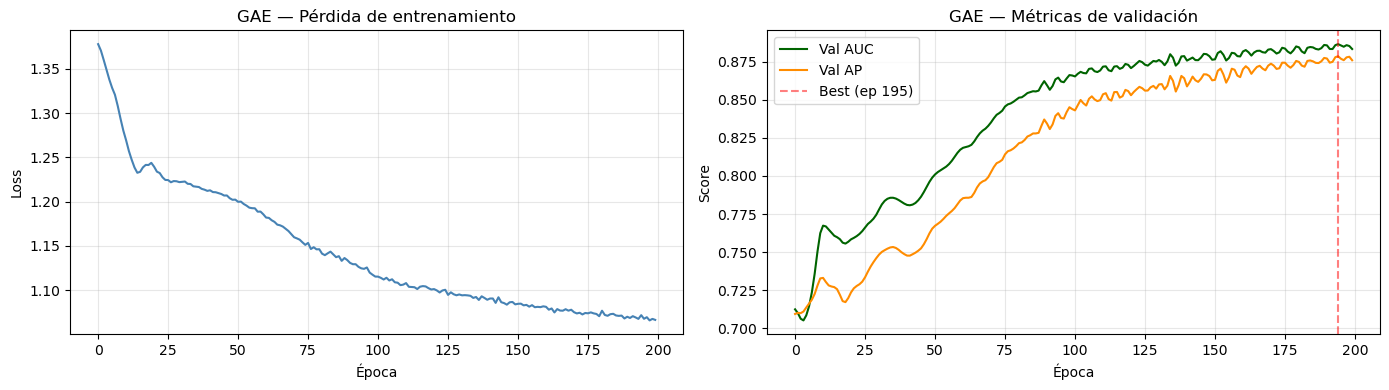

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(history_gae['loss'], color='steelblue')
axes[0].set_xlabel('Época'); axes[0].set_ylabel('Loss')
axes[0].set_title('GAE — Pérdida de entrenamiento')
axes[0].grid(alpha=0.3)
axes[1].plot(history_gae['val_auc'], label='Val AUC', color='darkgreen')
axes[1].plot(history_gae['val_ap'],  label='Val AP',  color='darkorange')
axes[1].axvline(best_epoch - 1, color='red', linestyle='--', alpha=0.5, label=f'Best (ep {best_epoch})')
axes[1].set_xlabel('Época'); axes[1].set_ylabel('Score')
axes[1].set_title('GAE — Métricas de validación')
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 5. Cálculo de anomaly scores (GAE)### 5.1 Score 1 — Error de reconstrucción (anomalía estructural)Para cada nodo $i$, comparamos su fila real de la matriz de adyacencia $A_i$ con su fila reconstruida $\hat{A}_i = \sigma(Z z_i^T)$. Usamos **BCE** entre ambos:$$s^{rec}_i = -\frac{1}{N}\sum_{j} A_{ij} \log \hat{A}_{ij} + (1 - A_{ij}) \log(1 - \hat{A}_{ij})$$Un nodo cuyo patrón de conexiones no se reconstruye bien tiene un score alto — es una señal de **anomalía estructural**: su vecindad es atípica respecto al patrón global aprendido por la GCN.### 5.2 Score 2 — Distancia al centroide (anomalía de atributo)$$s^{lat}_i = \| z_i - \bar{z} \|_2$$donde $\bar{z}$ es el centroide de todos los embeddings. El espacio latente integra información topológica y de features — los nodos que se alejan del centroide tienen una **combinación inusual de atributos y estructura**, lo que puede revelar anomalías de atributo que no se detectan solo mirando las conexiones.**Implementación eficiente:** la matriz completa $A$ es 11.371 × 11.371 (~129M entradas). El cálculo se vectoriza por bloques de filas para no agotar memoria.

In [10]:
@torch.no_grad()
def get_embeddings(model, data):
    model.eval()
    return model.encode(data.x, data.edge_index)


@torch.no_grad()
def reconstruction_error_per_node(z, edge_index, num_nodes, batch_size=512):
    """
    Error de reconstrucción BCE por nodo, vectorizado por bloques.
    Se usa el edge_index COMPLETO del grafo original (no solo el split de train)
    para evaluar qué tan bien el modelo reconstruye TODAS las conexiones reales.
    """
    device_z = z.device
    src, dst = edge_index[0], edge_index[1]
    errors = torch.zeros(num_nodes, device=device_z)

    for start in range(0, num_nodes, batch_size):
        end = min(start + batch_size, num_nodes)
        z_block = z[start:end]
        logits = z_block @ z.t()
        targets = torch.zeros_like(logits)
        mask = (src >= start) & (src < end)
        local_src = src[mask] - start
        local_dst = dst[mask]
        targets[local_src, local_dst] = 1.0
        bce = F.binary_cross_entropy_with_logits(logits, targets, reduction='none')
        errors[start:end] = bce.mean(dim=1)

    return errors.cpu().numpy()


z_gae = get_embeddings(model_gae, train_data)
print(f'Embeddings shape: {z_gae.shape}')

full_edge_index = data_M.edge_index.to(device)
recon_err_gae = reconstruction_error_per_node(z_gae, full_edge_index, data_M.num_nodes)
print(f'Reconstruction error — min={recon_err_gae.min():.4f}, max={recon_err_gae.max():.4f}, mean={recon_err_gae.mean():.4f}')

z_np = z_gae.cpu().numpy()
centroid = z_np.mean(axis=0)
latent_dist_gae = np.linalg.norm(z_np - centroid, axis=1)
print(f'Latent distance   — min={latent_dist_gae.min():.4f}, max={latent_dist_gae.max():.4f}, mean={latent_dist_gae.mean():.4f}')

Embeddings shape: torch.Size([11371, 16])
Reconstruction error — min=0.6023, max=1.4096, mean=0.7874
Latent distance   — min=0.1750, max=8.2618, mean=1.2119


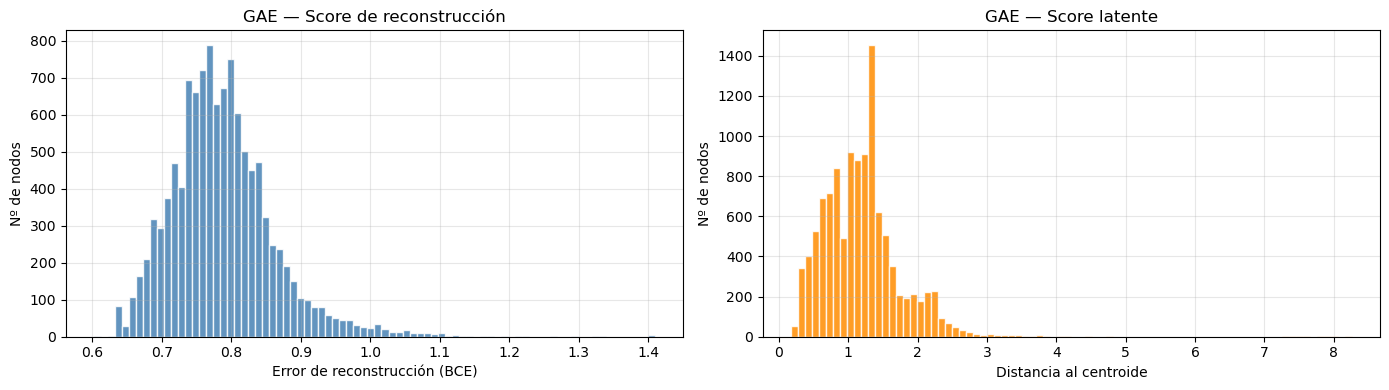

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(recon_err_gae, bins=80, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_xlabel('Error de reconstrucción (BCE)'); axes[0].set_ylabel('Nº de nodos')
axes[0].set_title('GAE — Score de reconstrucción'); axes[0].grid(alpha=0.3)
axes[1].hist(latent_dist_gae, bins=80, color='darkorange', edgecolor='white', alpha=0.85)
axes[1].set_xlabel('Distancia al centroide'); axes[1].set_ylabel('Nº de nodos')
axes[1].set_title('GAE — Score latente'); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 6. Arquitectura y entrenamiento del VGAE### 6.1 Fundamento teóricoEl **Variational Graph Autoencoder** sustituye el embedding determinista por una **distribución gaussiana**: cada nodo se proyecta a $q(z_i \mid X, A) = \mathcal{N}(\mu_i, \text{diag}(\sigma_i^2))$.El embedding se obtiene por el **truco de reparametrización**:$$z_i = \mu_i + \sigma_i \odot \epsilon, \quad \epsilon \sim \mathcal{N}(0, I)$$La pérdida añade un término de regularización **KL-divergence** que empuja la distribución posterior aprendida hacia un prior gaussiano estándar:$$\mathcal{L}_{VGAE} = \mathcal{L}_{rec} + \frac{1}{N} \text{KL}[q(Z \mid X, A) \| p(Z)]$$### 6.2 Diferencias prácticas con el GAE- **Espacio latente más estructurado:** la regularización KL fuerza a que el espacio latente sea continuo y suave.- **Cuantificación de incertidumbre:** el modelo aprende no solo $\mu_i$ sino también $\sigma_i^2$ — una varianza alta indica que el modelo es menos seguro de la representación del nodo.- **KL residual en grafos grandes:** en grafos de >10k nodos la KL tiende a ser muy pequeña comparada con la pérdida de reconstrucción, ya que el término $1/N$ la normaliza agresivamente. Es lo que ocurre en M (KL ~0.004 en época 200), lo cual es normal y esperado.

In [12]:
class VariationalGCNEncoder(nn.Module):
    """
    Encoder variacional: capa GCN compartida + dos cabezas finales (mu y logvar).
    """
    def __init__(self, in_channels, hidden_channels, out_channels, dropout=0.2):
        super().__init__()
        self.conv_shared = GCNConv(in_channels, hidden_channels, cached=True)
        self.conv_mu     = GCNConv(hidden_channels, out_channels, cached=True)
        self.conv_logvar = GCNConv(hidden_channels, out_channels, cached=True)
        self.dropout = dropout

    def forward(self, x, edge_index):
        x = self.conv_shared(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        return self.conv_mu(x, edge_index), self.conv_logvar(x, edge_index)


torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

model_vgae = VGAE(VariationalGCNEncoder(IN_DIM, HIDDEN_DIM, LATENT_DIM)).to(device)
print(model_vgae)

VGAE(
  (encoder): VariationalGCNEncoder(
    (conv_shared): GCNConv(3, 32)
    (conv_mu): GCNConv(32, 16)
    (conv_logvar): GCNConv(32, 16)
  )
  (decoder): InnerProductDecoder()
)


In [13]:
def train_epoch_vgae(model, data, optimizer):
    model.train()
    optimizer.zero_grad()
    z = model.encode(data.x, data.edge_index)
    loss = model.recon_loss(z, data.pos_edge_label_index)
    kl_loss = (1 / data.num_nodes) * model.kl_loss()
    total_loss = loss + kl_loss
    total_loss.backward()
    optimizer.step()
    return float(total_loss), float(loss), float(kl_loss)


@torch.no_grad()
def eval_split_vgae(model, data):
    model.eval()
    z = model.encode(data.x, data.edge_index)
    return model.test(z, data.pos_edge_label_index, data.neg_edge_label_index)

In [14]:
optimizer_vgae = torch.optim.Adam(model_vgae.parameters(), lr=LR)

history_vgae = {'loss': [], 'rec': [], 'kl': [], 'val_auc': [], 'val_ap': []}
best_val_auc_v = 0.0
best_epoch_v = 0
patience_counter = 0
best_state_v = None

for epoch in range(1, EPOCHS + 1):
    total, rec, kl = train_epoch_vgae(model_vgae, train_data, optimizer_vgae)
    val_auc, val_ap = eval_split_vgae(model_vgae, val_data)

    history_vgae['loss'].append(total)
    history_vgae['rec'].append(rec)
    history_vgae['kl'].append(kl)
    history_vgae['val_auc'].append(val_auc)
    history_vgae['val_ap'].append(val_ap)

    if val_auc > best_val_auc_v:
        best_val_auc_v = val_auc
        best_epoch_v = epoch
        patience_counter = 0
        best_state_v = {k: v.detach().clone() for k, v in model_vgae.state_dict().items()}
    else:
        patience_counter += 1

    if epoch % 10 == 0 or epoch == 1:
        print(f'Epoch {epoch:3d} | Total {total:.4f} | Rec {rec:.4f} | KL {kl:.4f} | '
              f'Val AUC {val_auc:.4f} | Val AP {val_ap:.4f}')

    if patience_counter >= PATIENCE:
        print(f'\nEarly stopping en época {epoch}. Mejor época: {best_epoch_v} (Val AUC {best_val_auc_v:.4f})')
        break

if best_state_v is not None:
    model_vgae.load_state_dict(best_state_v)

test_auc_v, test_ap_v = eval_split_vgae(model_vgae, test_data)
print(f'\n=== Resultados finales VGAE ===')
print(f'Test AUC: {test_auc_v:.4f}')
print(f'Test AP : {test_ap_v:.4f}')

Epoch   1 | Total 3.4821 | Rec 3.4821 | KL 0.0000 | Val AUC 0.7516 | Val AP 0.7026
Epoch  10 | Total 2.3487 | Rec 2.3486 | KL 0.0001 | Val AUC 0.7596 | Val AP 0.7398
Epoch  20 | Total 1.4235 | Rec 1.4228 | KL 0.0007 | Val AUC 0.7790 | Val AP 0.7441
Epoch  30 | Total 1.2649 | Rec 1.2634 | KL 0.0015 | Val AUC 0.7776 | Val AP 0.7347
Epoch  40 | Total 1.2282 | Rec 1.2262 | KL 0.0021 | Val AUC 0.8000 | Val AP 0.7615
Epoch  50 | Total 1.2064 | Rec 1.2040 | KL 0.0024 | Val AUC 0.8108 | Val AP 0.7800
Epoch  60 | Total 1.1897 | Rec 1.1871 | KL 0.0026 | Val AUC 0.8213 | Val AP 0.7926
Epoch  70 | Total 1.1706 | Rec 1.1679 | KL 0.0027 | Val AUC 0.8330 | Val AP 0.8081
Epoch  80 | Total 1.1543 | Rec 1.1515 | KL 0.0028 | Val AUC 0.8450 | Val AP 0.8240
Epoch  90 | Total 1.1337 | Rec 1.1308 | KL 0.0029 | Val AUC 0.8562 | Val AP 0.8377
Epoch 100 | Total 1.1216 | Rec 1.1186 | KL 0.0031 | Val AUC 0.8666 | Val AP 0.8485
Epoch 110 | Total 1.1143 | Rec 1.1111 | KL 0.0032 | Val AUC 0.8668 | Val AP 0.8491
Epoc

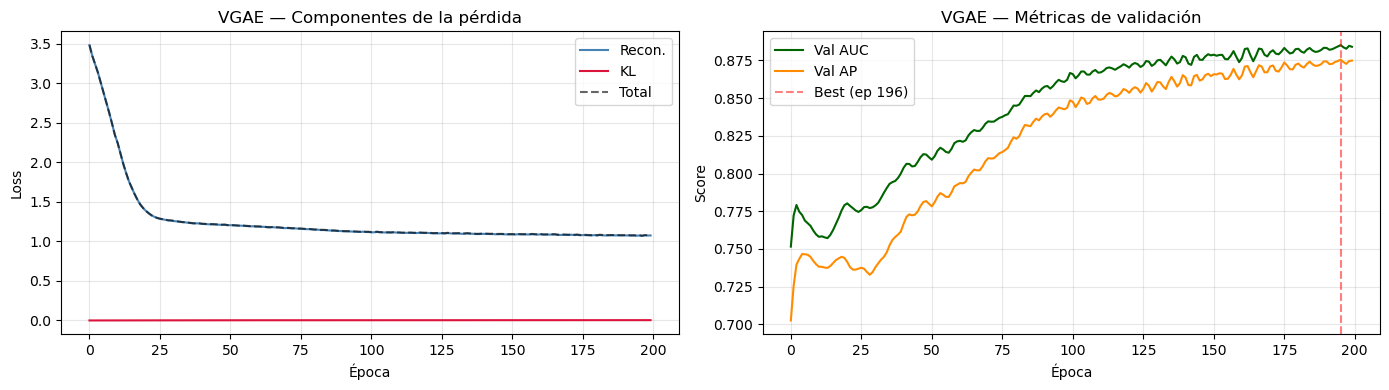

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(history_vgae['rec'], label='Recon.', color='steelblue')
axes[0].plot(history_vgae['kl'],  label='KL',     color='crimson')
axes[0].plot(history_vgae['loss'], label='Total',  color='black', linestyle='--', alpha=0.6)
axes[0].set_xlabel('Época'); axes[0].set_ylabel('Loss')
axes[0].set_title('VGAE — Componentes de la pérdida')
axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].plot(history_vgae['val_auc'], label='Val AUC', color='darkgreen')
axes[1].plot(history_vgae['val_ap'],  label='Val AP',  color='darkorange')
axes[1].axvline(best_epoch_v - 1, color='red', linestyle='--', alpha=0.5, label=f'Best (ep {best_epoch_v})')
axes[1].set_xlabel('Época'); axes[1].set_ylabel('Score')
axes[1].set_title('VGAE — Métricas de validación')
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 7. Anomaly scores (VGAE)Repetimos el cálculo de los dos scores con el VGAE. Usamos $\mu_i$ como embedding determinista — más estable que muestrear y suficiente para detección de anomalías. En modo `eval()`, PyG devuelve directamente $\mu_i$ sin muestreo.

In [16]:
@torch.no_grad()
def get_embeddings_vgae(model, data):
    model.eval()
    return model.encode(data.x, data.edge_index)


z_vgae = get_embeddings_vgae(model_vgae, train_data)
print(f'VGAE embeddings shape: {z_vgae.shape}')

recon_err_vgae = reconstruction_error_per_node(z_vgae, full_edge_index, data_M.num_nodes)
print(f'Reconstruction error — min={recon_err_vgae.min():.4f}, max={recon_err_vgae.max():.4f}, mean={recon_err_vgae.mean():.4f}')

z_vgae_np = z_vgae.cpu().numpy()
centroid_v = z_vgae_np.mean(axis=0)
latent_dist_vgae = np.linalg.norm(z_vgae_np - centroid_v, axis=1)
print(f'Latent distance   — min={latent_dist_vgae.min():.4f}, max={latent_dist_vgae.max():.4f}, mean={latent_dist_vgae.mean():.4f}')

VGAE embeddings shape: torch.Size([11371, 16])
Reconstruction error — min=0.6293, max=1.3710, mean=0.7845
Latent distance   — min=0.1832, max=6.6506, mean=1.1948


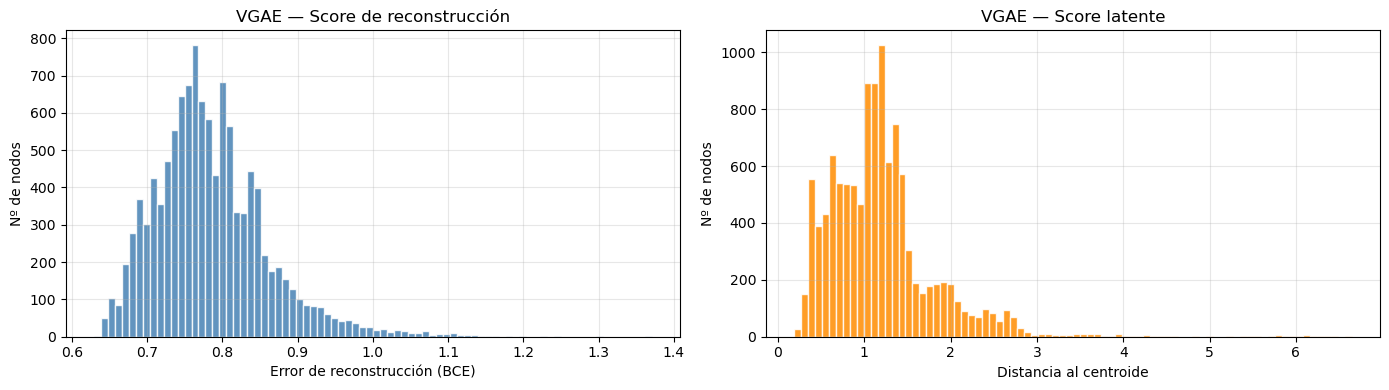

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(recon_err_vgae, bins=80, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_xlabel('Error de reconstrucción (BCE)'); axes[0].set_ylabel('Nº de nodos')
axes[0].set_title('VGAE — Score de reconstrucción'); axes[0].grid(alpha=0.3)
axes[1].hist(latent_dist_vgae, bins=80, color='darkorange', edgecolor='white', alpha=0.85)
axes[1].set_xlabel('Distancia al centroide'); axes[1].set_ylabel('Nº de nodos')
axes[1].set_title('VGAE — Score latente'); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 8. Comparativa GAE vs VGAEComparamos los dos modelos en tres dimensiones:1. **Métricas de evaluación** (AUC, AP en test).2. **Correlación de rankings** (Spearman): ¿identifican los mismos nodos como anómalos en el mismo orden relativo?3. **Solapamiento del top-K**: de los 100 nodos más anómalos según cada modelo, ¿cuántos coinciden literalmente?

In [18]:
from scipy.stats import spearmanr

metrics_df = pd.DataFrame({
    'Modelo':     ['GAE', 'VGAE'],
    'Test AUC':   [test_auc, test_auc_v],
    'Test AP':    [test_ap,  test_ap_v],
    'Best epoch': [best_epoch, best_epoch_v],
})
print('=== Comparativa de modelos ===')
print(metrics_df.to_string(index=False))

print('\n=== Correlación de rankings (Spearman) ===')
pairs = [
    ('GAE-rec',   'VGAE-rec',  recon_err_gae,   recon_err_vgae),
    ('GAE-lat',   'VGAE-lat',  latent_dist_gae, latent_dist_vgae),
    ('GAE-rec',   'GAE-lat',   recon_err_gae,   latent_dist_gae),
    ('VGAE-rec',  'VGAE-lat',  recon_err_vgae,  latent_dist_vgae),
]
for n1, n2, s1, s2 in pairs:
    rho, _ = spearmanr(s1, s2)
    print(f'  {n1:10s} vs {n2:10s}: ρ = {rho:.4f}')

K = 100
print(f'\n=== Solapamiento del top-{K} ===')
for n1, n2, s1, s2 in pairs:
    top1 = set(np.argsort(-s1)[:K])
    top2 = set(np.argsort(-s2)[:K])
    overlap = len(top1 & top2) / K
    print(f'  {n1:10s} vs {n2:10s}: {overlap:.2%}')

=== Comparativa de modelos ===
Modelo  Test AUC  Test AP  Best epoch
   GAE  0.883051 0.874715         195
  VGAE  0.882139 0.872478         196

=== Correlación de rankings (Spearman) ===
  GAE-rec    vs VGAE-rec  : ρ = 0.9656
  GAE-lat    vs VGAE-lat  : ρ = 0.9779
  GAE-rec    vs GAE-lat   : ρ = 0.4564
  VGAE-rec   vs VGAE-lat  : ρ = 0.3385

=== Solapamiento del top-100 ===
  GAE-rec    vs VGAE-rec  : 85.00%
  GAE-lat    vs VGAE-lat  : 71.00%
  GAE-rec    vs GAE-lat   : 22.00%
  VGAE-rec   vs VGAE-lat  : 17.00%


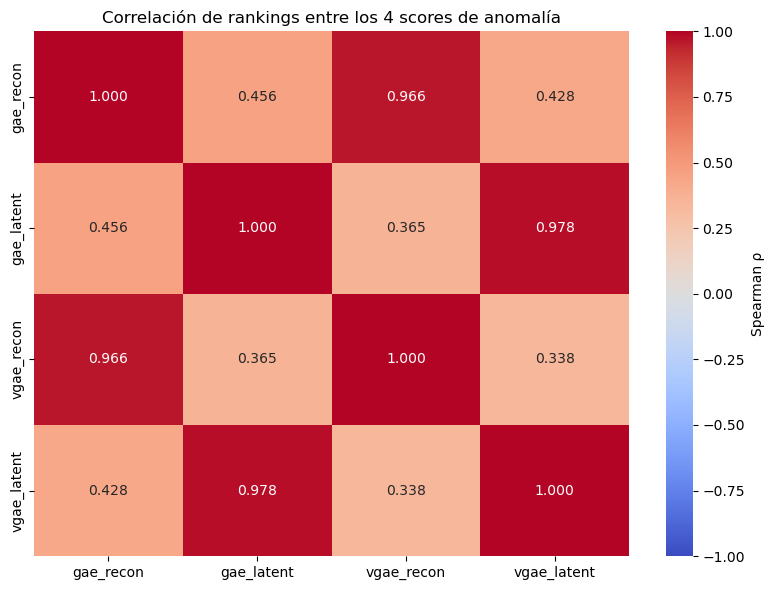

In [19]:
def normalize(x):
    return (x - x.min()) / (x.max() - x.min() + 1e-9)

scores_norm = pd.DataFrame({
    'gae_recon':   normalize(recon_err_gae),
    'gae_latent':  normalize(latent_dist_gae),
    'vgae_recon':  normalize(recon_err_vgae),
    'vgae_latent': normalize(latent_dist_vgae),
})

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(scores_norm.corr(method='spearman'), annot=True, cmap='coolwarm',
            center=0, vmin=-1, vmax=1, ax=ax, fmt='.3f',
            cbar_kws={'label': 'Spearman ρ'})
ax.set_title('Correlación de rankings entre los 4 scores de anomalía')
plt.tight_layout(); plt.show()

## 9. Análisis de anomalías detectadasConstruimos la tabla de scores por nodo cruzada con `meta_members`.**Nota sobre el cálculo del grado.** El grado de cada nodo se calcula sobre `data_M.edge_index` — el grafo completo **antes del split** — dividido por 2 (ya que `edge_index` duplica cada arista no dirigida). Esto garantiza que los grados reflejan la conectividad real del grafo y no el subconjunto de aristas de entrenamiento, lo que es crucial para identificar correctamente los nodos hoja (grado = 1) y los super-conectores.

In [20]:
member_ids_M = data_M.member_ids

scores_full = pd.DataFrame({
    'idx':         np.arange(data_M.num_nodes),
    'member_id':   member_ids_M,
    'gae_recon':   recon_err_gae,
    'gae_latent':  latent_dist_gae,
    'vgae_recon':  recon_err_vgae,
    'vgae_latent': latent_dist_vgae,
})

# Grado calculado sobre el grafo COMPLETO (edge_index original, antes del split)
degree = torch.zeros(data_M.num_nodes, dtype=torch.long)
degree.scatter_add_(
    0,
    data_M.edge_index[0].cpu(),
    torch.ones(data_M.edge_index.shape[1], dtype=torch.long)
)
scores_full['degree'] = degree.numpy() // 2  # /2: cada arista no dirigida está duplicada

scores_full = scores_full.merge(
    meta_members[['member_id', 'name', 'city', 'state']],
    on='member_id', how='left'
)

print(f'Shape: {scores_full.shape}')
print(f'Nodos hoja (grado=1)     : {(scores_full["degree"] == 1).sum()}')
print(f'Super-conectores (>500)  : {(scores_full["degree"] > 500).sum()}')
scores_full.head()

Shape: (11371, 10)
Nodos hoja (grado=1)     : 54
Super-conectores (>500)  : 97


,idx,member_id,gae_recon,gae_latent,vgae_recon,vgae_latent,degree,name,city,state
0,0,2069,0.883644,1.046545,0.899705,1.093525,219,Wesley Duffee-Braun,Brentwood,TN
1,1,8386,0.906837,1.231441,0.882585,1.142538,307,Tim,Nashville,TN
2,2,9205,0.917162,1.367162,0.930227,1.361880,334,Brenda,Brentwood,TN
3,3,42506,0.740548,0.676003,0.744828,0.613791,122,Chris Meador,Nashville,TN
4,4,106758,0.814867,1.218716,0.810655,1.143283,119,Kt,Antioch,TN


In [21]:
print('=== Top 20 — GAE reconstruction error ===')
print(scores_full.nlargest(20, 'gae_recon')[
    ['member_id','name','city','state','degree','gae_recon']].to_string(index=False))

=== Top 20 — GAE reconstruction error ===
 member_id                  name            city state  degree  gae_recon
   4184723                 Peggy  Hendersonville    TN       3   1.409599
  79152872          Holly Miller       Hermitage    TN       3   1.409599
   9728295          Sue Knuckles       Nashville    TN       3   1.405250
 151916002     Christine Jackson       Nashville    TN       3   1.405250
 217882384         Kristie Meyer          Renton    WA       3   1.405250
   3949436                 Pablo       Nashville    TN     688   1.331595
   6944107                Joan D       Nashville    TN       3   1.327691
 223167558         Georgia Nejus  Goodlettsville    TN       3   1.294368
   5900662         Matt Kenigson       Nashville    TN     905   1.261354
 223204425                    RJ       Nashville    TN       1   1.222843
   8539046               Shalini       Nashville    TN     955   1.218432
 126066112 Taylor Michael Matson       Nashville    TN     731   1.215

In [22]:
print('=== Top 20 — GAE latent distance ===')
print(scores_full.nlargest(20, 'gae_latent')[
    ['member_id','name','city','state','degree','gae_latent']].to_string(index=False))

=== Top 20 — GAE latent distance ===
 member_id              name              city state  degree  gae_latent
   4184723             Peggy    Hendersonville    TN       3    8.261791
  79152872      Holly Miller         Hermitage    TN       3    8.261791
 195697902    Chelsea Siegel           Chicago    IL      19    8.137997
   9728295      Sue Knuckles         Nashville    TN       3    8.058035
 151916002 Christine Jackson         Nashville    TN       3    8.058034
 217882384     Kristie Meyer            Renton    WA       3    8.058034
  13486911      Dennis McGee           Chicago    IL      19    7.976384
  83080482        Jacqueline           Chicago    IL      19    7.930179
 187005263          Mellissa           Chicago    IL      19    7.929581
  88902572     Ryan Modreske           Chicago    IL      19    7.841317
 157219632         Neel Goel           Chicago    IL      19    7.821619
 173427802      Sarah Galvin          Oak Lawn    IL      19    7.771782
 184141812    

In [23]:
print('=== Top 20 — VGAE reconstruction error ===')
print(scores_full.nlargest(20, 'vgae_recon')[
    ['member_id','name','city','state','degree','vgae_recon']].to_string(index=False))

=== Top 20 — VGAE reconstruction error ===
 member_id                  name      city state  degree  vgae_recon
   3949436                 Pablo Nashville    TN     688    1.370957
   5900662         Matt Kenigson Nashville    TN     905    1.301030
 126066112 Taylor Michael Matson Nashville    TN     731    1.247963
   8539046               Shalini Nashville    TN     955    1.231117
 206481851           Adia Tigney Nashville    TN     638    1.195727
  15446041     Samuel Palaparthy Nashville    TN     771    1.178806
 127214502       Bryan P Marlowe    Smyrna    TN     639    1.159982
  81924252               Theresa Nashville    TN     887    1.157319
 138867992            Trent Hand Nashville    TN     588    1.144172
  60195472     Karthik Kornalies Nashville    TN     560    1.139305
  49816142            Kim Higdon Nashville    TN     448    1.138191
  11149295           Zack Benner Nashville    TN     571    1.134930
 203244569             Calvin J.   Antioch    TN     605    

In [24]:
print('=== Top 20 — VGAE latent distance ===')
print(scores_full.nlargest(20, 'vgae_latent')[
    ['member_id','name','city','state','degree','vgae_latent']].to_string(index=False))

=== Top 20 — VGAE latent distance ===
 member_id              name           city state  degree  vgae_latent
 204309536 John Ryan Kitchen       Brisbane   NaN       9     6.650588
   4184723             Peggy Hendersonville    TN       3     6.461753
  79152872      Holly Miller      Hermitage    TN       3     6.461753
 195697902    Chelsea Siegel        Chicago    IL      19     6.395168
   9728295      Sue Knuckles      Nashville    TN       3     6.286993
 151916002 Christine Jackson      Nashville    TN       3     6.286993
 217882384     Kristie Meyer         Renton    WA       3     6.286993
  13486911      Dennis McGee        Chicago    IL      19     6.267735
 187005263          Mellissa        Chicago    IL      19     6.239423
  83080482        Jacqueline        Chicago    IL      19     6.238119
  88902572     Ryan Modreske        Chicago    IL      19     6.167676
 157219632         Neel Goel        Chicago    IL      19     6.154585
 184141812           Ricardo        Chi

In [25]:
# Nodos hoja — con umbral correcto (grado = 1 sobre el grafo completo)
leaf_nodes = scores_full[scores_full['degree'] == 1]
print(f'Nodos hoja (grado=1 en el grafo completo): {len(leaf_nodes)}')
print('\n=== Posición de cada nodo hoja en el ranking de cada score ===')
for _, row in leaf_nodes.iterrows():
    rank_gr = (scores_full['gae_recon']   > row['gae_recon']).sum()   + 1
    rank_gl = (scores_full['gae_latent']  > row['gae_latent']).sum()  + 1
    rank_vr = (scores_full['vgae_recon']  > row['vgae_recon']).sum()  + 1
    rank_vl = (scores_full['vgae_latent'] > row['vgae_latent']).sum() + 1
    print(f"  {str(row['name'])[:30]:30s} | GAE-rec #{rank_gr:5d} | GAE-lat #{rank_gl:5d} | "
          f"VGAE-rec #{rank_vr:5d} | VGAE-lat #{rank_vl:5d}")

Nodos hoja (grado=1 en el grafo completo): 54

=== Posición de cada nodo hoja en el ranking de cada score ===
  paulrsmith                     | GAE-rec #10438 | GAE-lat # 5280 | VGAE-rec #10503 | VGAE-lat # 5551
  rbedwell                       | GAE-rec # 2305 | GAE-lat # 1272 | VGAE-rec # 3005 | VGAE-lat # 1794
  Micah Redding                  | GAE-rec # 9489 | GAE-lat #11371 | VGAE-rec # 9134 | VGAE-lat #11368
  Gabriel                        | GAE-rec # 9490 | GAE-lat #11370 | VGAE-rec # 9134 | VGAE-lat #11367
  Dominique                      | GAE-rec #   28 | GAE-lat #  110 | VGAE-rec #   70 | VGAE-lat #  222
  Chris Mule'                    | GAE-rec #10619 | GAE-lat #  377 | VGAE-rec #10405 | VGAE-lat #  533
  Ari                            | GAE-rec # 4223 | GAE-lat # 1638 | VGAE-rec # 4953 | VGAE-lat # 2274
  Patricia                       | GAE-rec # 4764 | GAE-lat # 5278 | VGAE-rec # 5635 | VGAE-lat # 4304
  Aaron Farris                   | GAE-rec #10680 | GAE-lat #  801

In [26]:
# Super-conectores — umbral 500 para capturar el grupo que el EDA identificó
# como estructuralmente relevante (Shalini 955, Matt 905, Theresa 887, Jim H 1178, etc.)
super_nodes = scores_full[scores_full['degree'] > 500].sort_values('degree', ascending=False)
print(f'Super-conectores (grado > 500): {len(super_nodes)}')
print('\n=== Super-conectores y su ranking de anomalía ===')
for _, row in super_nodes.iterrows():
    rank_gr = (scores_full['gae_recon']   > row['gae_recon']).sum()   + 1
    rank_gl = (scores_full['gae_latent']  > row['gae_latent']).sum()  + 1
    rank_vr = (scores_full['vgae_recon']  > row['vgae_recon']).sum()  + 1
    rank_vl = (scores_full['vgae_latent'] > row['vgae_latent']).sum() + 1
    print(f"  {str(row['name'])[:25]:25s} | grado {row['degree']:5d} | "
          f"GAE-rec #{rank_gr:5d} | GAE-lat #{rank_gl:5d} | "
          f"VGAE-rec #{rank_vr:5d} | VGAE-lat #{rank_vl:5d}")

Super-conectores (grado > 500): 97

=== Super-conectores y su ranking de anomalía ===
  Jim H                     | grado  1178 | GAE-rec #   50 | GAE-lat #   66 | VGAE-rec #   38 | VGAE-lat #   77
  Shalini                   | grado   955 | GAE-rec #   11 | GAE-lat #   81 | VGAE-rec #    4 | VGAE-lat #  110
  Omar Ali                  | grado   946 | GAE-rec #   37 | GAE-lat #  114 | VGAE-rec #   18 | VGAE-lat #  133
  Matt Kenigson             | grado   905 | GAE-rec #    9 | GAE-lat #   79 | VGAE-rec #    2 | VGAE-lat #   90
  Theresa                   | grado   887 | GAE-rec #   15 | GAE-lat #   92 | VGAE-rec #    8 | VGAE-lat #  122
  Michelle McManus          | grado   821 | GAE-rec #   91 | GAE-lat #  296 | VGAE-rec #   58 | VGAE-lat #  489
  Ted                       | grado   810 | GAE-rec #   41 | GAE-lat #  118 | VGAE-rec #   41 | VGAE-lat #  142
  Andrew Clement            | grado   784 | GAE-rec #  232 | GAE-lat #  364 | VGAE-rec #  187 | VGAE-lat #  597
  Rav             

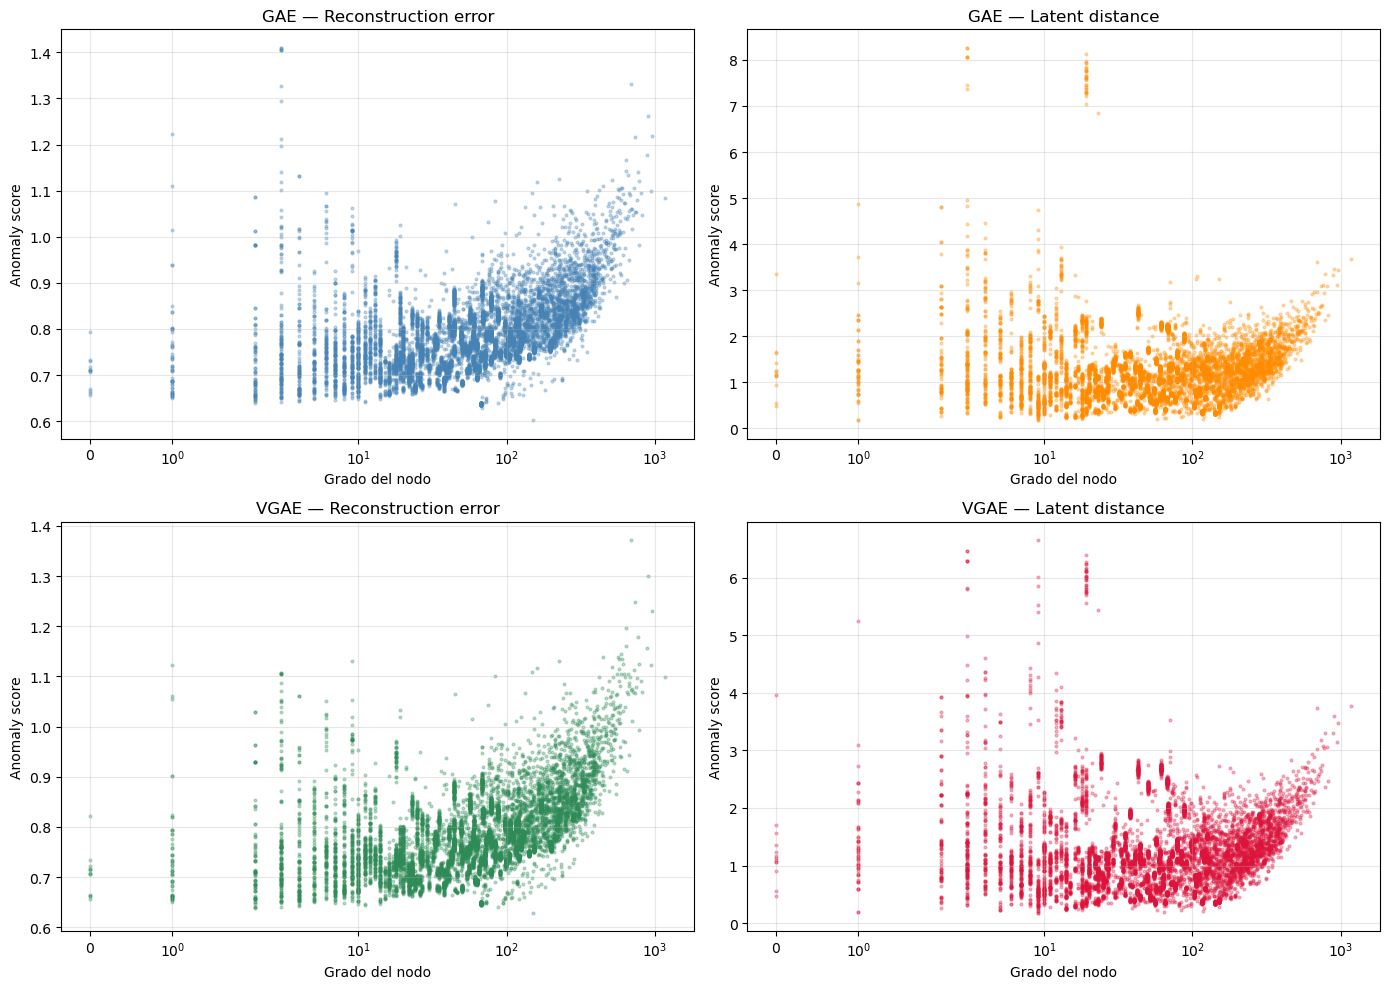

In [27]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
scatters = [
    ('gae_recon',   'GAE — Reconstruction error',  axes[0, 0], 'steelblue'),
    ('gae_latent',  'GAE — Latent distance',        axes[0, 1], 'darkorange'),
    ('vgae_recon',  'VGAE — Reconstruction error', axes[1, 0], 'seagreen'),
    ('vgae_latent', 'VGAE — Latent distance',       axes[1, 1], 'crimson'),
]
for col, title, ax, color in scatters:
    ax.scatter(scores_full['degree'], scores_full[col], s=4, alpha=0.3, color=color)
    ax.set_xlabel('Grado del nodo'); ax.set_ylabel('Anomaly score')
    ax.set_title(title); ax.set_xscale('symlog'); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 10. Guardado de resultadosGuardamos la tabla de scores, los embeddings y el historial de entrenamiento. En la sección 11 actualizaremos el CSV con el score de consenso y la tipología.

In [28]:
scores_full.to_csv(os.path.join(RESULTS_PATH, 'scores_M.csv'), index=False)
print(f'Guardado: {RESULTS_PATH}scores_M.csv  ({scores_full.shape})')

np.savez(
    os.path.join(RESULTS_PATH, 'embeddings_M.npz'),
    z_gae=z_np,
    z_vgae=z_vgae_np,
    member_ids=np.array(member_ids_M),
)
print(f'Guardado: {RESULTS_PATH}embeddings_M.npz')

import json
history_export = {
    'gae':  {k: list(map(float, v)) for k, v in history_gae.items()},
    'vgae': {k: list(map(float, v)) for k, v in history_vgae.items()},
    'metrics': {
        'gae':  {'test_auc': float(test_auc),   'test_ap': float(test_ap),   'best_epoch': int(best_epoch)},
        'vgae': {'test_auc': float(test_auc_v), 'test_ap': float(test_ap_v), 'best_epoch': int(best_epoch_v)},
    },
    'config': {
        'hidden_dim': HIDDEN_DIM, 'latent_dim': LATENT_DIM,
        'lr': LR, 'epochs': EPOCHS, 'patience': PATIENCE, 'seed': SEED,
    }
}
with open(os.path.join(RESULTS_PATH, 'history_M.json'), 'w') as f:
    json.dump(history_export, f, indent=2)
print(f'Guardado: {RESULTS_PATH}history_M.json')

Guardado: ../data/results/scores_M.csv  ((11371, 10))
Guardado: ../data/results/embeddings_M.npz
Guardado: ../data/results/history_M.json


## 11. Score de consenso y tipología de anomalías
### 11.1 Score de consenso — ranking unificadoTenemos cuatro scores distintos (GAE-rec, GAE-lat, VGAE-rec, VGAE-lat). Para el análisis del TFM y para poder comparar entre grafos necesitamos **un único ranking final** que agregue la señal de todos ellos. Usamos el **rango percentil promedio** en lugar de la media de los valores normalizados. La razón es que los scores tienen distribuciones de forma muy diferente — uno puede ser muy concentrado con algunos outliers extremos y otro más uniforme — por lo que normalizar a [0,1] por min-max puede distorsionar el peso relativo. Transformar a percentiles antes de promediar hace que cada score contribuya por igual independientemente de su distribución.$$s^{consensus}_i = \frac{1}{4} \left( \text{pct}(s^{rec}_{GAE})_i + \text{pct}(s^{lat}_{GAE})_i + \text{pct}(s^{rec}_{VGAE})_i + \text{pct}(s^{lat}_{VGAE})_i \right)$$donde $\text{pct}(s)_i$ es el percentil del nodo $i$ en la distribución del score $s$.
### 11.2 Tipología de anomalías — estructural vs atributo vs mixtaLa literatura de detección de anomalías en grafos con atributos distingue dos tipos fundamentales (Ding et al., 2019 — *Deep Anomaly Detection on Attributed Networks*):- **Anomalía estructural**: el patrón de conexiones del nodo es inusual respecto al resto de la red. La señal principal es el **error de reconstrucción**: si el modelo no puede predecir bien las conexiones de un nodo, es porque esa vecindad no se parece a ningún patrón aprendido.- **Anomalía de atributo**: las features del nodo son inusuales, pero sus conexiones pueden ser perfectamente normales. La señal principal es la **distancia al centroide latente**: el embedding del nodo se aleja del centro del espacio porque sus atributos (o la combinación de atributos y estructura local) no se parece a los patrones predominantes.- **Anomalía mixta**: alta señal en ambas dimensiones. Son los candidatos más sólidos, porque múltiples fuentes de evidencia apuntan en la misma dirección.Implementamos esta tipología usando los percentiles de cada score. Un nodo es "alto" en una dimensión si su score supera el umbral del percentil 90 — lo que equivale a estar en el 10% más extremo del grafo en esa señal.

In [29]:
from scipy.stats import rankdata

def to_percentile(arr):
    """Transforma un array de scores a percentiles en [0, 100]."""
    return rankdata(arr) / len(arr) * 100


# Percentiles de los cuatro scores
pct_gae_recon   = to_percentile(recon_err_gae)
pct_gae_latent  = to_percentile(latent_dist_gae)
pct_vgae_recon  = to_percentile(recon_err_vgae)
pct_vgae_latent = to_percentile(latent_dist_vgae)

# Score de consenso: media de los cuatro percentiles
consensus_score = (pct_gae_recon + pct_gae_latent + pct_vgae_recon + pct_vgae_latent) / 4

scores_full['pct_gae_recon']   = pct_gae_recon
scores_full['pct_gae_latent']  = pct_gae_latent
scores_full['pct_vgae_recon']  = pct_vgae_recon
scores_full['pct_vgae_latent'] = pct_vgae_latent
scores_full['consensus_score'] = consensus_score

print('=== Score de consenso — distribución ===')
print(f'  min  : {consensus_score.min():.2f}')
print(f'  media: {consensus_score.mean():.2f}')
print(f'  p90  : {np.percentile(consensus_score, 90):.2f}')
print(f'  p95  : {np.percentile(consensus_score, 95):.2f}')
print(f'  max  : {consensus_score.max():.2f}')

=== Score de consenso — distribución ===
  min  : 4.04
  media: 50.00
  p90  : 83.65
  p95  : 90.86
  max  : 99.94


In [30]:
# Umbral para clasificar una señal como "alta": percentil 90
# Significa que el nodo está en el 10% más extremo del grafo en esa dimensión
P_THRESH = 90

# Señales por dimensión: promedio de GAE y VGAE del mismo tipo
# - Señal estructural: promedio de pct de los dos scores de reconstrucción
# - Señal de atributo: promedio de pct de los dos scores latentes
scores_full['signal_structural'] = (pct_gae_recon  + pct_vgae_recon)  / 2
scores_full['signal_attribute']  = (pct_gae_latent + pct_vgae_latent) / 2

high_struct = scores_full['signal_structural'] >= P_THRESH
high_attrib = scores_full['signal_attribute']  >= P_THRESH

# Tipología
def assign_type(row):
    hs = row['signal_structural'] >= P_THRESH
    ha = row['signal_attribute']  >= P_THRESH
    if hs and ha:
        return 'Mixta'
    elif hs:
        return 'Estructural'
    elif ha:
        return 'Atributo'
    else:
        return 'Normal'

scores_full['anomaly_type'] = scores_full.apply(assign_type, axis=1)

print('=== Distribución de tipos de anomalía ===')
print(scores_full['anomaly_type'].value_counts().to_string())
print(f'\nTotal anomalías detectadas: {(scores_full["anomaly_type"] != "Normal").sum()} '
      f'({(scores_full["anomaly_type"] != "Normal").mean():.1%} del grafo)')

=== Distribución de tipos de anomalía ===
anomaly_type
Normal         9524
Atributo        725
Estructural     704
Mixta           418

Total anomalías detectadas: 1847 (16.2% del grafo)


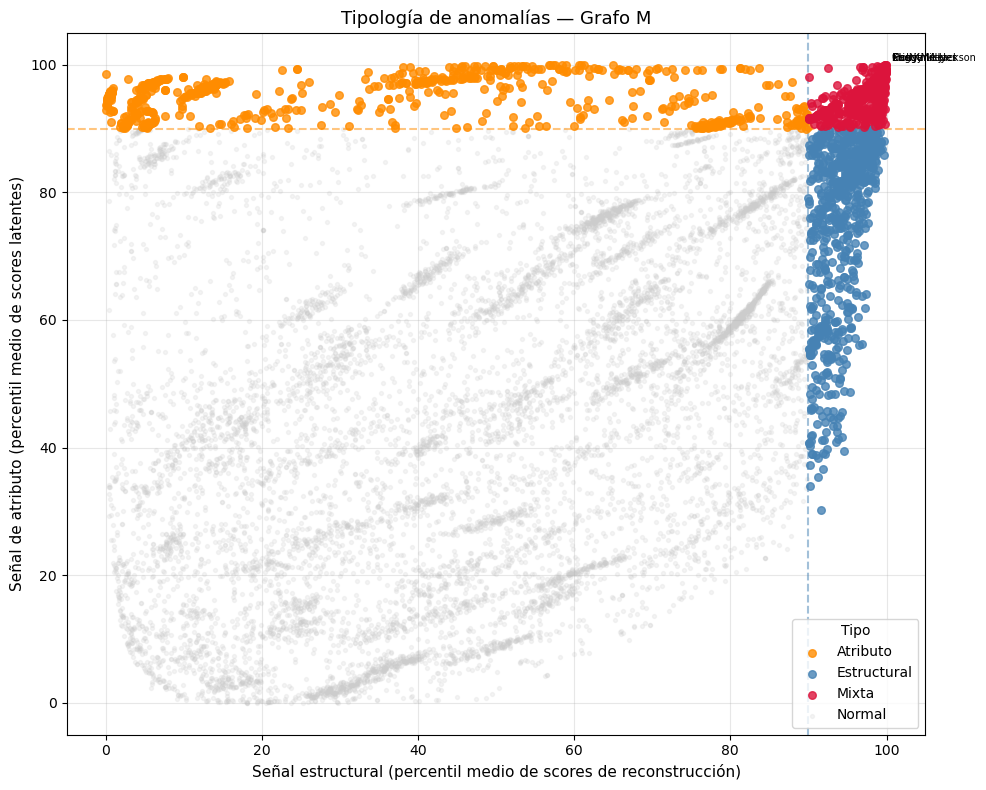

In [31]:
# Visualización: scatter signal_structural vs signal_attribute
# coloreado por tipo — la figura más interpretable del capítulo 7.1
fig, ax = plt.subplots(figsize=(10, 8))

colors = {'Normal': '#cccccc', 'Estructural': 'steelblue',
          'Atributo': 'darkorange', 'Mixta': 'crimson'}

for atype, group in scores_full.groupby('anomaly_type'):
    size  = 30 if atype != 'Normal' else 8
    alpha = 0.8 if atype != 'Normal' else 0.2
    ax.scatter(group['signal_structural'], group['signal_attribute'],
               s=size, alpha=alpha, color=colors[atype], label=atype, zorder=3 if atype != 'Normal' else 1)

# Líneas de umbral
ax.axvline(P_THRESH, color='steelblue', linestyle='--', alpha=0.5)
ax.axhline(P_THRESH, color='darkorange', linestyle='--', alpha=0.5)

# Etiquetas de los nodos más extremos
top_mix = scores_full[scores_full['anomaly_type'] == 'Mixta'].nlargest(5, 'consensus_score')
for _, row in top_mix.iterrows():
    ax.annotate(str(row['name'])[:20],
                (row['signal_structural'], row['signal_attribute']),
                fontsize=7, xytext=(5, 3), textcoords='offset points')

ax.set_xlabel('Señal estructural (percentil medio de scores de reconstrucción)', fontsize=11)
ax.set_ylabel('Señal de atributo (percentil medio de scores latentes)', fontsize=11)
ax.set_title('Tipología de anomalías — Grafo M', fontsize=13)
ax.legend(title='Tipo', fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [32]:
# Top 20 por score de consenso
print('=== Top 20 — Score de consenso (ranking unificado) ===')
top20_consensus = scores_full.nlargest(20, 'consensus_score')[
    ['name', 'city', 'state', 'degree', 'anomaly_type',
     'signal_structural', 'signal_attribute', 'consensus_score']
]
print(top20_consensus.to_string(index=False))

=== Top 20 — Score de consenso (ranking unificado) ===
                 name            city state  degree anomaly_type  signal_structural  signal_attribute  consensus_score
                Peggy  Hendersonville    TN       3        Mixta          99.890071         99.991206        99.940638
         Holly Miller       Hermitage    TN       3        Mixta          99.890071         99.991206        99.940638
         Sue Knuckles       Nashville    TN       3        Mixta          99.857093         99.964823        99.910958
        Kristie Meyer          Renton    WA       3        Mixta          99.850497         99.958227        99.904362
    Christine Jackson       Nashville    TN       3        Mixta          99.843901         99.958227        99.901064
    John Ryan Kitchen        Brisbane   NaN       9        Mixta          99.643831         99.819717        99.731774
               Joan D       Nashville    TN       3        Mixta          99.617448         99.771348        99.

## 12. Spotlight — candidatos identificados en el EDAEn el EDA del grafo M se identificaron varios candidatos a anomalía con justificación estructural sólida. Esta sección los verifica sistemáticamente contra los scores del modelo — es el núcleo de la sección 8.2 del TFM ("anomalías detectadas vs candidatos del EDA").Los candidatos a verificar son:| Candidato | Razón del EDA ||---|---|| **Pablo** | Degree moderada (688) pero betweenness desproporcionadamente alta (#3 de toda la red) — puente estructural extremo || **Shalini** | Mayor betweenness de toda la red (0.021), segunda en degree (955) || **Jim H** | Super-conector más extremo (grado 1.178) y simultáneamente puente inter-comunidad (ratio 0.759) || **Matt Kenigson** | Grado 905, super-conector relevante || **GEEK by AKEIN Engineering** | Entidad empresarial no personal — anomalía de naturaleza del nodo || **Microcomunidades C2 y C21** | Grupos de 13 y 6 nodos completamente periféricos, betweenness = 0 || **John Ryan Kitchen** | Brisbane, Australia — estado NaN, aparece en el top VGAE-latent || **Cluster de Chicago** | ~15 miembros de Chicago (IL) con grado 19 que dominan el score latente |

In [33]:
def get_member_scores(name_fragment, scores_df):
    """Busca un miembro por fragmento de nombre y devuelve sus scores completos."""
    matches = scores_df[scores_df['name'].str.contains(name_fragment, case=False, na=False)]
    if len(matches) == 0:
        return None
    return matches

def print_spotlight(row, scores_df, label=None):
    """Imprime el perfil completo de anomalía de un nodo."""
    n = scores_df.shape[0]
    rank_gr = (scores_df['gae_recon']   > row['gae_recon']).sum()   + 1
    rank_gl = (scores_df['gae_latent']  > row['gae_latent']).sum()  + 1
    rank_vr = (scores_df['vgae_recon']  > row['vgae_recon']).sum()  + 1
    rank_vl = (scores_df['vgae_latent'] > row['vgae_latent']).sum() + 1
    rank_cs = (scores_df['consensus_score'] > row['consensus_score']).sum() + 1

    tag = label or str(row['name'])
    print(f'  ► {tag}')
    print(f'    Ciudad: {row["city"]} ({row["state"]}) | Grado: {row["degree"]} | Tipo: {row["anomaly_type"]}')
    print(f'    Señal estructural: {row["signal_structural"]:.1f}p | Señal atributo: {row["signal_attribute"]:.1f}p')
    print(f'    Rankings  GAE-rec #{rank_gr:5d}/{n} | GAE-lat #{rank_gl:5d}/{n} | '
          f'VGAE-rec #{rank_vr:5d}/{n} | VGAE-lat #{rank_vl:5d}/{n}')
    print(f'    Consenso: #{rank_cs:5d}/{n}  (score: {row["consensus_score"]:.1f})')
    print()

In [34]:
print('=' * 70)
print('CANDIDATOS DEL EDA — VERIFICACIÓN DE SCORES')
print('=' * 70)

# 1. Pablo — puente estructural extremo
pablo = get_member_scores('Pablo', scores_full)
if pablo is not None:
    for _, row in pablo.head(1).iterrows():
        print_spotlight(row, scores_full, label='Pablo (alta betweenness, degree moderada)')

# 2. Shalini — mayor betweenness de la red
shalini = get_member_scores('Shalini', scores_full)
if shalini is not None:
    for _, row in shalini.head(1).iterrows():
        print_spotlight(row, scores_full, label='Shalini (mayor betweenness de la red)')

# 3. Jim H — super-conector extremo y puente inter-comunidad
jimh = get_member_scores('Jim H', scores_full)
if jimh is not None:
    for _, row in jimh.head(1).iterrows():
        print_spotlight(row, scores_full, label='Jim H (super-conector + puente inter-comunidad)')

# 4. Matt Kenigson
matt = get_member_scores('Matt Kenigson', scores_full)
if matt is not None:
    for _, row in matt.head(1).iterrows():
        print_spotlight(row, scores_full, label='Matt Kenigson (super-conector)')

# 5. GEEK by AKEIN — entidad empresarial
geek = get_member_scores('GEEK', scores_full)
if geek is not None:
    for _, row in geek.head(1).iterrows():
        print_spotlight(row, scores_full, label='GEEK by AKEIN Engineering (entidad no personal)')

# 6. John Ryan Kitchen — miembro internacional (Brisbane, NaN state)
jrk = get_member_scores('John Ryan Kitchen', scores_full)
if jrk is not None:
    for _, row in jrk.head(1).iterrows():
        print_spotlight(row, scores_full, label='John Ryan Kitchen (Brisbane, Australia — estado NaN)')

CANDIDATOS DEL EDA — VERIFICACIÓN DE SCORES
  ► Pablo (alta betweenness, degree moderada)
    Ciudad: Nashville (TN) | Grado: 688 | Tipo: Mixta
    Señal estructural: 100.0p | Señal atributo: 99.4p
    Rankings  GAE-rec #    6/11371 | GAE-lat #   70/11371 | VGAE-rec #    1/11371 | VGAE-lat #   79/11371
    Consenso: #    8/11371  (score: 99.7)

  ► Shalini (mayor betweenness de la red)
    Ciudad: Nashville (TN) | Grado: 955 | Tipo: Mixta
    Señal estructural: 99.9p | Señal atributo: 99.2p
    Rankings  GAE-rec #   11/11371 | GAE-lat #   81/11371 | VGAE-rec #    4/11371 | VGAE-lat #  110/11371
    Consenso: #   13/11371  (score: 99.6)

  ► Jim H (super-conector + puente inter-comunidad)
    Ciudad: Nashville (TN) | Grado: 1178 | Tipo: Mixta
    Señal estructural: 99.6p | Señal atributo: 99.4p
    Rankings  GAE-rec #   50/11371 | GAE-lat #   66/11371 | VGAE-rec #   38/11371 | VGAE-lat #   77/11371
    Consenso: #   15/11371  (score: 99.5)

  ► Matt Kenigson (super-conector)
    Ciudad:

In [35]:
# 7. Cluster de Chicago — anomalía de atributo emergente
# Estos miembros no eran candidatos explícitos del EDA pero el score latente los
# señala consistentemente. Son un hallazgo nuevo que el modelo aporta.
chicago = scores_full[scores_full['city'] == 'Chicago'].sort_values('consensus_score', ascending=False)
print(f'Miembros de Chicago en el grafo M: {len(chicago)}')
print('\n=== Top 10 miembros de Chicago por consensus score ===')
print(chicago.head(10)[['name','state','degree','anomaly_type',
                         'signal_structural','signal_attribute','consensus_score']].to_string(index=False))

print('\n--- Distribución de tipos para el cluster de Chicago ---')
print(chicago['anomaly_type'].value_counts().to_string())

Miembros de Chicago en el grafo M: 40

=== Top 10 miembros de Chicago por consensus score ===
          name state  degree anomaly_type  signal_structural  signal_attribute  consensus_score
Chelsea Siegel    IL      19     Atributo          65.011872         99.978014        82.494943
        ScottS    IL      88       Normal          73.678656         89.139038        81.408847
  Dennis McGee    IL      19     Atributo          61.239117         99.942837        80.590977
      Mellissa    IL      19     Atributo          60.856565         99.929646        80.393105
    Jacqueline    IL      19     Atributo          60.667487         99.929646        80.298567
 Ryan Modreske    IL      19     Atributo          58.930613         99.916454        79.423534
     Neel Goel    IL      19     Atributo          58.446926         99.907660        79.177293
Danielle McGee    IL     268       Normal          86.443585         71.396535        78.920060
       Ricardo    IL      19     Atributo 

In [44]:
import networkx as nx

# Cargamos el GraphML con las etiquetas de comunidad Louvain ya calculadas en el EDA
G_nx = nx.read_graphml('../graphs/graphml_cluster/member_graph_cluster.graphml')

# Extraemos el atributo de cluster por nodo — el nombre exacto del atributo
# puede variar según cómo se guardó; lo inspeccionamos primero
sample_node = list(G_nx.nodes(data=True))[0]
print(f'Atributos disponibles en los nodos: {list(sample_node[1].keys())}')

Atributos disponibles en los nodos: ['name', 'city', 'state', 'lat', 'lon', 'community_louvain']


In [45]:
list(G_nx.nodes())[0]

'198737924'

In [48]:
import networkx as nx

# Cargamos el GraphML con las etiquetas de comunidad Louvain calculadas en el EDA
G_nx = nx.read_graphml('../graphs/graphml_cluster/member_graph_cluster.graphml')

# Extraemos community_louvain por nodo y construimos un DataFrame de mapeo
community_map = {
    int(node_id): data['community_louvain']
    for node_id, data in G_nx.nodes(data=True)
    if 'community_louvain' in data
}
community_df = pd.DataFrame.from_dict(community_map, orient='index', columns=['community_louvain'])
community_df.index.name = 'member_id'
community_df = community_df.reset_index()

# Cruzamos con scores_full
scores_full = scores_full.merge(community_df, on='member_id', how='left')

print(f'Nodos con etiqueta de comunidad: {scores_full["community_louvain"].notna().sum()} / {len(scores_full)}')
print(f'Nodos sin etiqueta (no estaban en el GraphML): {scores_full["community_louvain"].isna().sum()}')
print(f'\nDistribución de comunidades:\n{scores_full["community_louvain"].value_counts().to_string()}')

Nodos con etiqueta de comunidad: 11371 / 11371
Nodos sin etiqueta (no estaban en el GraphML): 0

Distribución de comunidades:
community_louvain
11    2215
8     1651
4     1049
7      927
17     772
19     667
14     569
9      513
6      508
18     392
15     335
13     329
5      302
16     277
3      209
1      206
0      170
20     133
12      80
10      48
2       13
21       6


In [49]:
# 8. Microcomunidades C2 y C21
# Ahora que tenemos las etiquetas reales de Louvain podemos identificar directamente
# los nodos de las microcomunidades C2 (13 nodos) y C21 (6 nodos) del EDA.
# En el EDA estas eran las dos comunidades más periféricas, completamente aisladas,
# con betweenness = 0 en todos sus miembros.

# Identificamos qué IDs de comunidad corresponden a C2 y C21
# mirando las comunidades con menos nodos
community_sizes = scores_full['community_louvain'].value_counts()
print('=== Tamaño de todas las comunidades ===')
print(community_sizes.sort_values().to_string())

# Las dos comunidades más pequeñas deberían ser C2 (13 nodos) y C21 (6 nodos)
micro_communities = community_sizes[community_sizes <= 15].index.tolist()
print(f'\nMicrocomunidades identificadas (<=15 nodos): {micro_communities}')

micro_nodes = scores_full[scores_full['community_louvain'].isin(micro_communities)]
print(f'Total nodos en microcomunidades: {len(micro_nodes)}')
print('\n=== Nodos de microcomunidades y sus scores ===')
print(micro_nodes[['name', 'city', 'state', 'degree', 'community_louvain',
                    'anomaly_type', 'signal_structural', 'signal_attribute',
                    'consensus_score']].sort_values(
                        ['community_louvain', 'consensus_score'], ascending=[True, False]
                    ).to_string(index=False))

=== Tamaño de todas las comunidades ===
community_louvain
21       6
2       13
10      48
12      80
20     133
0      170
1      206
3      209
16     277
5      302
13     329
15     335
18     392
6      508
9      513
14     569
19     667
17     772
7      927
4     1049
8     1651
11    2215

Microcomunidades identificadas (<=15 nodos): [2, 21]
Total nodos en microcomunidades: 19

=== Nodos de microcomunidades y sus scores ===
              name         city state  degree  community_louvain anomaly_type  signal_structural  signal_attribute  consensus_score
       Katie Britt    Nashville    TN       7                  2  Estructural          95.229092         88.884003        92.056547
        M.E. Sorci    Nashville    TN       7                  2  Estructural          93.610940         88.549820        91.080380
         Catherine    Nashville    TN       7                  2  Estructural          93.017325         87.696772        90.357049
            alicia    Nashville   

In [50]:
# Análisis de anomalías por comunidad — ¿qué comunidades concentran más anomalías?
community_anomaly = scores_full.groupby('community_louvain').agg(
    total_nodos=('member_id', 'count'),
    n_anomalias=('anomaly_type', lambda x: (x != 'Normal').sum()),
    n_mixta=('anomaly_type', lambda x: (x == 'Mixta').sum()),
    n_estructural=('anomaly_type', lambda x: (x == 'Estructural').sum()),
    n_atributo=('anomaly_type', lambda x: (x == 'Atributo').sum()),
    consensus_mean=('consensus_score', 'mean'),
    consensus_max=('consensus_score', 'max'),
).reset_index()

community_anomaly['pct_anomalia'] = (
    community_anomaly['n_anomalias'] / community_anomaly['total_nodos'] * 100
).round(1)

community_anomaly = community_anomaly.sort_values('pct_anomalia', ascending=False)

print('=== Tasa de anomalía por comunidad Louvain ===')
print(community_anomaly.to_string(index=False))

=== Tasa de anomalía por comunidad Louvain ===
 community_louvain  total_nodos  n_anomalias  n_mixta  n_estructural  n_atributo  consensus_mean  consensus_max  pct_anomalia
                10           48           46        0              0          46       51.186498      52.926304          95.8
                 0          170          132       83              7          42       79.856032      98.309296          77.6
                 2           13            7        0              7           0       86.551653      92.056547          53.8
                20          133           60        0             30          30       69.593166      90.728608          45.1
                 6          508          150       50             51          49       75.020183      99.610852          29.5
                 9          513          147       23             28          96       53.972592      98.333480          28.7
                13          329           90        7             10   

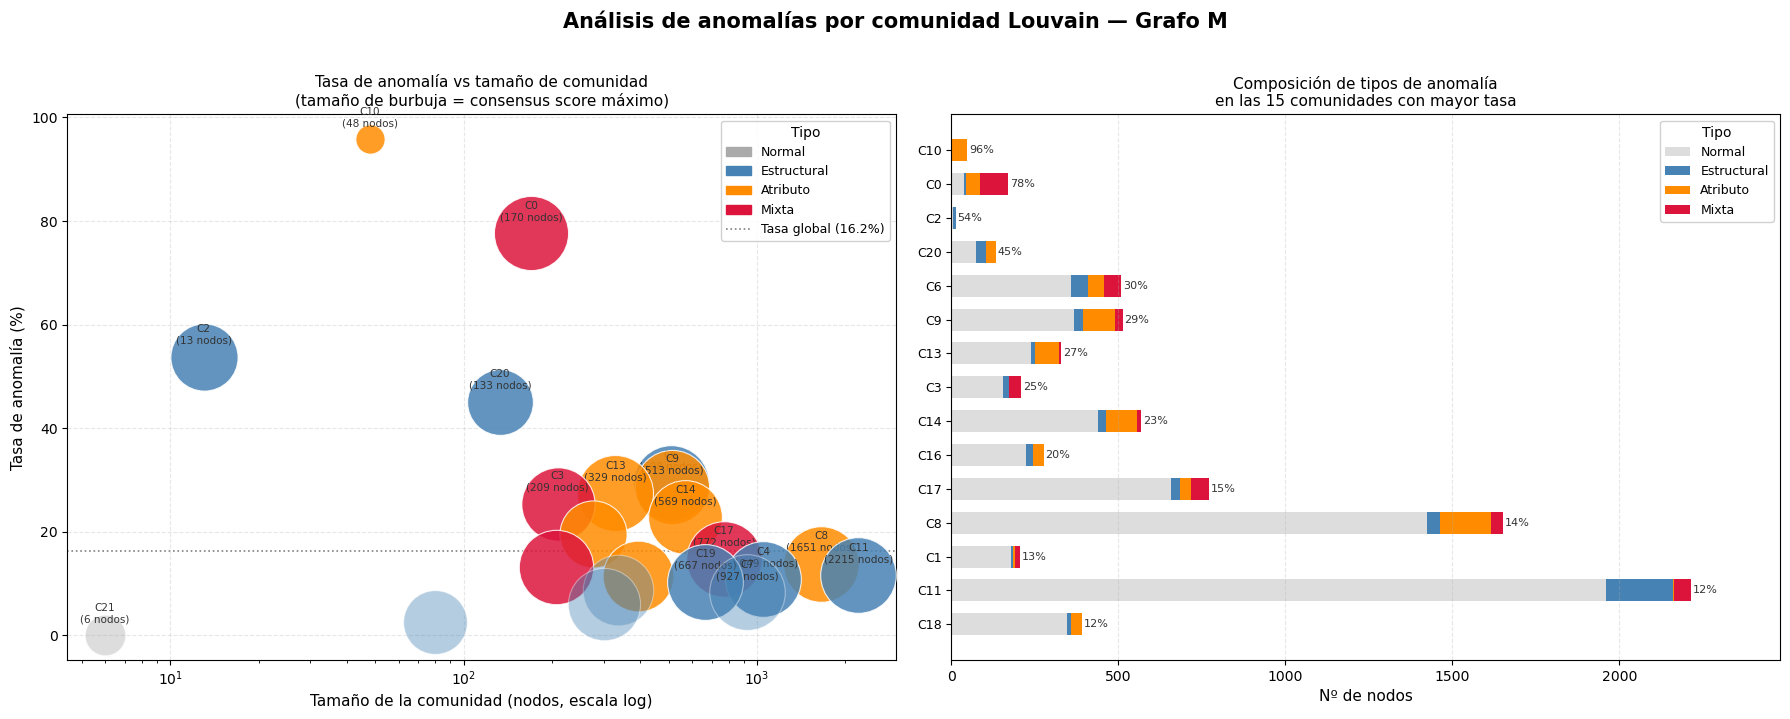

In [74]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# Orden fijo para ambas leyendas
TIPO_ORDER = ['Normal', 'Estructural', 'Atributo', 'Mixta']
color_map  = {'Normal': '#dddddd', 'Estructural': 'steelblue', 'Atributo': 'darkorange', 'Mixta': 'crimson'}

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Análisis de anomalías por comunidad Louvain — Grafo M', fontsize=15, fontweight='bold', y=1.02)
# ── Gráfico 1: Bubble chart comunidades ───────────────────────────────────────
ax = axes[0]

# Color por tipo dominante de anomalía en cada comunidad
def dominant_type(row):
    counts = {'Mixta': row['n_mixta'], 'Estructural': row['n_estructural'], 'Atributo': row['n_atributo']}
    dominant = max(counts, key=counts.get)
    return dominant if counts[dominant] > 0 else 'Normal'

community_anomaly['dominant_type'] = community_anomaly.apply(dominant_type, axis=1)

color_map = {'Mixta': 'crimson', 'Estructural': 'steelblue', 'Atributo': 'darkorange', 'Normal': '#aaaaaa'}

for _, row in community_anomaly.iterrows():
    color  = color_map[row['dominant_type']]
    size   = (row['consensus_max'] / 100) ** 3 * 3000   # escala cúbica para más contraste visual
    alpha  = 0.85 if row['pct_anomalia'] > 10 else 0.4
    ax.scatter(row['total_nodos'], row['pct_anomalia'],
               s=size, color=color, alpha=alpha, edgecolors='white', linewidths=0.8, zorder=3)

    # Etiquetamos comunidades notables: micros, las más anómalas, las más grandes
    label_conditions = (
        row['total_nodos'] <= 15 or          # microcomunidades
        row['pct_anomalia'] > 25 or          # tasa de anomalía muy alta
        row['total_nodos'] > 500             # comunidades gigantes
    )
    if label_conditions:
        label = f"C{int(row['community_louvain'])}\n({int(row['total_nodos'])} nodos)"
        ax.annotate(label,
                    (row['total_nodos'], row['pct_anomalia']),
                    fontsize=7.5, ha='center', va='bottom',
                    xytext=(0, 8), textcoords='offset points',
                    color='#333333')

ax.set_xscale('log')
ax.set_xlabel('Tamaño de la comunidad (nodos, escala log)', fontsize=11)
ax.set_ylabel('Tasa de anomalía (%)', fontsize=11)
ax.set_title('Tasa de anomalía vs tamaño de comunidad\n(tamaño de burbuja = consensus score máximo)', fontsize=11)
ax.grid(alpha=0.3, linestyle='--')
ax.axhline(scores_full['anomaly_type'].ne('Normal').mean() * 100,
           color='gray', linestyle=':', linewidth=1.2, label='Media global (16.2%)')
ax.legend(fontsize=9)

# Leyenda única arriba a la derecha — mismo orden que el bar chart
legend_patches = [mpatches.Patch(color=color_map[t], label=t) for t in TIPO_ORDER]
legend_patches.append(plt.Line2D([0], [0], color='gray', linestyle=':', linewidth=1.2, label=f'Tasa global ({global_rate:.1f}%)'))
ax.legend(handles=legend_patches, title='Tipo', fontsize=9,
          loc='upper right', framealpha=0.9)
# ── Gráfico 2: Stacked bar chart de tipos por comunidad ───────────────────────
ax2 = axes[1]

# Ordenamos por tasa de anomalía descendente y nos quedamos con las top 15
# más las microcomunidades — las más interesantes para el TFM
top_communities = community_anomaly.nlargest(15, 'pct_anomalia').copy()
top_communities = top_communities.sort_values('pct_anomalia', ascending=True)  # horizontal: de menos a más

labels = [f"C{int(c)}" for c in top_communities['community_louvain']]
n_normal     = top_communities['total_nodos'] - top_communities['n_anomalias']
n_estructural = top_communities['n_estructural']
n_atributo   = top_communities['n_atributo']
n_mixta      = top_communities['n_mixta']

y = np.arange(len(labels))
bar_h = 0.65

b1 = ax2.barh(y, n_normal,      bar_h, color='#dddddd',    label='Normal')
b2 = ax2.barh(y, n_estructural, bar_h, left=n_normal,                          color='steelblue',  label='Estructural')
b3 = ax2.barh(y, n_atributo,    bar_h, left=n_normal + n_estructural,          color='darkorange', label='Atributo')
b4 = ax2.barh(y, n_mixta,       bar_h, left=n_normal + n_estructural + n_atributo, color='crimson', label='Mixta')

# Porcentaje al final de cada barra
for i, (_, row) in enumerate(top_communities.iterrows()):
    ax2.text(row['total_nodos'] + 5, i, f"{row['pct_anomalia']:.0f}%",
             va='center', fontsize=8, color='#333333')

ax2.set_yticks(y)
ax2.set_yticklabels(labels, fontsize=9)
ax2.set_xlabel('Nº de nodos', fontsize=11)
ax2.set_title('Composición de tipos de anomalía\nen las 15 comunidades con mayor tasa', fontsize=11)
ax2.legend(title='Tipo', fontsize=9, loc='upper right', framealpha=0.9)
ax2.grid(alpha=0.3, axis='x', linestyle='--')
ax2.set_xlim(0, top_communities['total_nodos'].max() * 1.12)

plt.tight_layout()
plt.show()

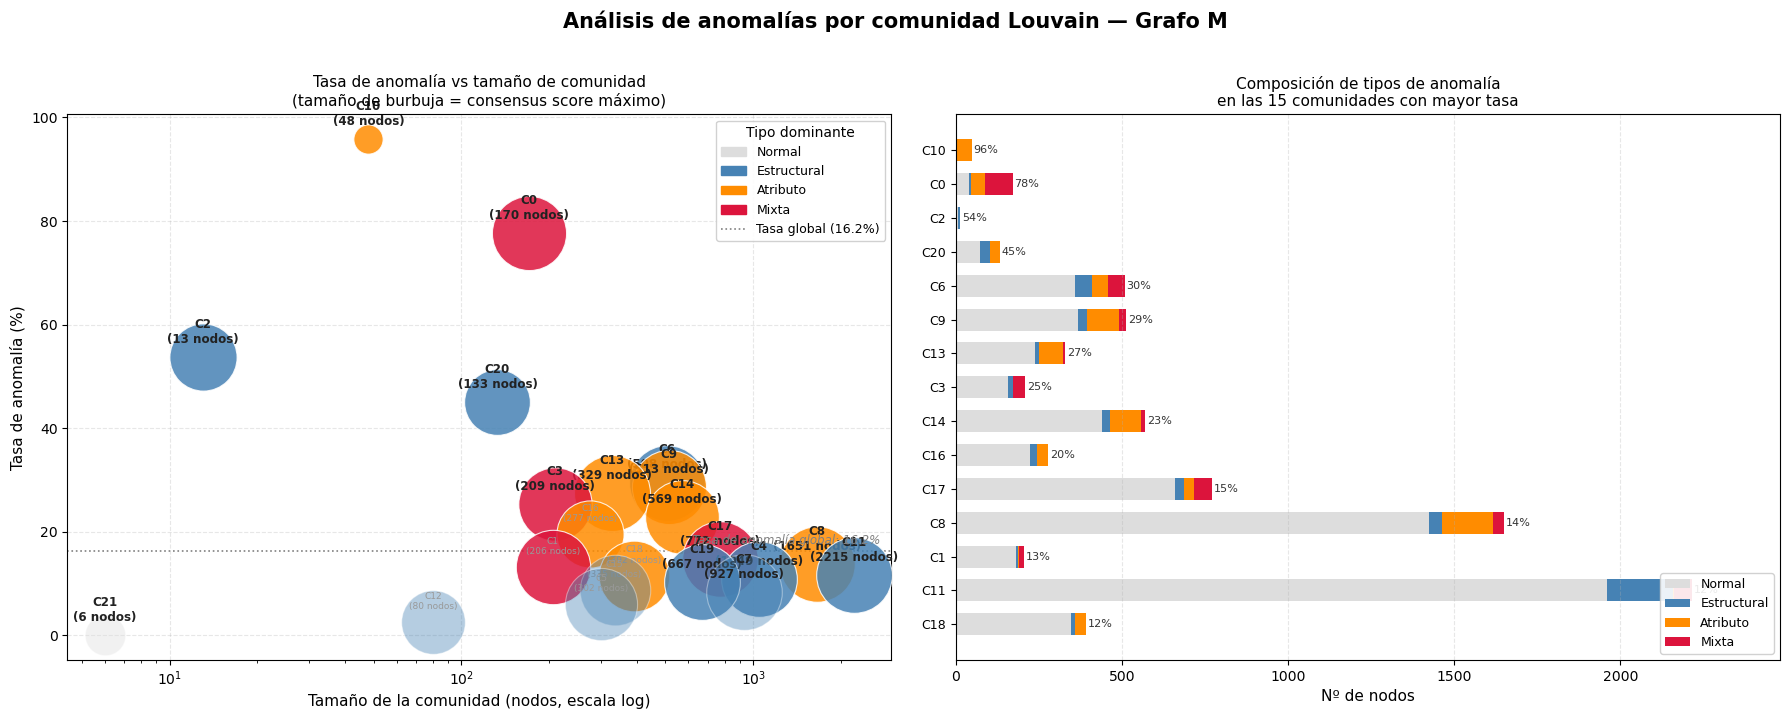

In [61]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# Orden fijo para ambas leyendas
TIPO_ORDER = ['Normal', 'Estructural', 'Atributo', 'Mixta']
color_map  = {'Normal': '#dddddd', 'Estructural': 'steelblue', 'Atributo': 'darkorange', 'Mixta': 'crimson'}

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Análisis de anomalías por comunidad Louvain — Grafo M', fontsize=15, fontweight='bold', y=1.02)

# ── Gráfico 1: Bubble chart comunidades ───────────────────────────────────────
ax = axes[0]

def dominant_type(row):
    counts = {'Mixta': row['n_mixta'], 'Estructural': row['n_estructural'], 'Atributo': row['n_atributo']}
    dominant = max(counts, key=counts.get)
    return dominant if counts[dominant] > 0 else 'Normal'

community_anomaly['dominant_type'] = community_anomaly.apply(dominant_type, axis=1)

for _, row in community_anomaly.iterrows():
    color  = color_map[row['dominant_type']]
    size   = (row['consensus_max'] / 100) ** 3 * 3000
    alpha  = 0.85 if row['pct_anomalia'] > 10 else 0.4
    ax.scatter(row['total_nodos'], row['pct_anomalia'],
               s=size, color=color, alpha=alpha, edgecolors='white', linewidths=0.8, zorder=3)

    notable = row['total_nodos'] <= 15 or row['pct_anomalia'] > 25 or row['total_nodos'] > 500
    label   = f"C{int(row['community_louvain'])}\n({int(row['total_nodos'])} nodos)"
    ax.annotate(label,
                (row['total_nodos'], row['pct_anomalia']),
                fontsize=8.5 if notable else 6.5,
                fontweight='bold' if notable else 'normal',
                ha='center', va='bottom',
                xytext=(0, 8), textcoords='offset points',
                color='#222222' if notable else '#999999')

ax.set_xscale('log')
ax.set_xlabel('Tamaño de la comunidad (nodos, escala log)', fontsize=11)
ax.set_ylabel('Tasa de anomalía (%)', fontsize=11)
ax.set_title('Tasa de anomalía vs tamaño de comunidad\n(tamaño de burbuja = consensus score máximo)', fontsize=11)
ax.grid(alpha=0.3, linestyle='--')

# Línea de tasa global con texto dentro del gráfico
global_rate = scores_full['anomaly_type'].ne('Normal').mean() * 100
ax.axhline(global_rate, color='gray', linestyle=':', linewidth=1.2)
ax.text(
    ax.get_xlim()[1] * 0.92,
    global_rate + 0.8,
    f'Tasa de anomalía global: {global_rate:.1f}%',
    ha='right', va='bottom',
    fontsize=8.5, color='gray', style='italic'
)

# Leyenda única arriba a la derecha — mismo orden que el bar chart
legend_patches = [mpatches.Patch(color=color_map[t], label=t) for t in TIPO_ORDER]
legend_patches.append(plt.Line2D([0], [0], color='gray', linestyle=':', linewidth=1.2, label=f'Tasa global ({global_rate:.1f}%)'))
ax.legend(handles=legend_patches, title='Tipo dominante', fontsize=9,
          loc='upper right', framealpha=0.9)

# ── Gráfico 2: Stacked bar chart de tipos por comunidad ───────────────────────
ax2 = axes[1]

top_communities = community_anomaly.nlargest(15, 'pct_anomalia').copy()
top_communities = top_communities.sort_values('pct_anomalia', ascending=True)

labels        = [f"C{int(c)}" for c in top_communities['community_louvain']]
n_normal      = top_communities['total_nodos'] - top_communities['n_anomalias']
n_estructural = top_communities['n_estructural']
n_atributo    = top_communities['n_atributo']
n_mixta       = top_communities['n_mixta']

y     = np.arange(len(labels))
bar_h = 0.65

ax2.barh(y, n_normal,      bar_h,                                             color=color_map['Normal'],      label='Normal')
ax2.barh(y, n_estructural, bar_h, left=n_normal,                              color=color_map['Estructural'], label='Estructural')
ax2.barh(y, n_atributo,    bar_h, left=n_normal + n_estructural,              color=color_map['Atributo'],    label='Atributo')
ax2.barh(y, n_mixta,       bar_h, left=n_normal + n_estructural + n_atributo, color=color_map['Mixta'],       label='Mixta')

for i, (_, row) in enumerate(top_communities.iterrows()):
    ax2.text(row['total_nodos'] + 5, i, f"{row['pct_anomalia']:.0f}%",
             va='center', fontsize=8, color='#333333')

ax2.set_yticks(y)
ax2.set_yticklabels(labels, fontsize=9)
ax2.set_xlabel('Nº de nodos', fontsize=11)
ax2.set_title('Composición de tipos de anomalía\nen las 15 comunidades con mayor tasa', fontsize=11)
ax2.legend(fontsize=9, loc='lower right', framealpha=0.9)
ax2.grid(alpha=0.3, axis='x', linestyle='--')
ax2.set_xlim(0, top_communities['total_nodos'].max() * 1.12)

plt.tight_layout()
plt.show()

In [36]:
# 8. Microcomunidades C2 y C21
# El EDA identificó dos microcomunidades completamente periféricas.
# No podemos acceder directamente a las etiquetas de comunidad desde aquí
# (se calcularon en el notebook de EDA), pero podemos identificar nodos
# con betweenness = 0 y grado muy bajo — características definitorias de esas comunidades.
peripheral = scores_full[
    (scores_full['degree'] <= 10) &
    (scores_full['degree'] >= 2)   # excluimos hojas para centrarnos en microcomunidades
].sort_values('consensus_score', ascending=False)
print(f'Nodos con grado 2-10 (candidatos a microcomunidades): {len(peripheral)}')
print('\n=== Top 15 de estos nodos por consensus score ===')
print(peripheral.head(15)[['name','city','state','degree','anomaly_type',
                            'signal_structural','signal_attribute','consensus_score']].to_string(index=False))

Nodos con grado 2-10 (candidatos a microcomunidades): 1001

=== Top 15 de estos nodos por consensus score ===
             name            city state  degree anomaly_type  signal_structural  signal_attribute  consensus_score
            Peggy  Hendersonville    TN       3        Mixta          99.890071         99.991206        99.940638
     Holly Miller       Hermitage    TN       3        Mixta          99.890071         99.991206        99.940638
     Sue Knuckles       Nashville    TN       3        Mixta          99.857093         99.964823        99.910958
    Kristie Meyer          Renton    WA       3        Mixta          99.850497         99.958227        99.904362
Christine Jackson       Nashville    TN       3        Mixta          99.843901         99.958227        99.901064
John Ryan Kitchen        Brisbane   NaN       9        Mixta          99.643831         99.819717        99.731774
           Joan D       Nashville    TN       3        Mixta          99.617448      

In [37]:
# Resumen ejecutivo de los candidatos del EDA
print('=' * 70)
print('RESUMEN: ¿Qué capturó el modelo que el EDA ya anticipó?')
print('=' * 70)

candidatos = {
    'Pablo':             ('Pablo',             'puente estructural extremo'),
    'Shalini':           ('Shalini',           'mayor betweenness de la red'),
    'Jim H':             ('Jim H',             'super-conector + puente inter-comunidad'),
    'Matt Kenigson':     ('Matt Kenigson',     'super-conector'),
    'GEEK by AKEIN':     ('GEEK',              'entidad empresarial no personal'),
    'John Ryan Kitchen': ('John Ryan Kitchen', 'miembro internacional'),
}

rows_summary = []
for label, (frag, desc) in candidatos.items():
    match = get_member_scores(frag, scores_full)
    if match is None or len(match) == 0:
        continue
    row = match.iloc[0]
    rank_cs = (scores_full['consensus_score'] > row['consensus_score']).sum() + 1
    rows_summary.append({
        'Candidato':        label,
        'Descripción EDA':  desc,
        'Tipo anomalía':    row['anomaly_type'],
        'Señal estr. (p)':  round(row['signal_structural'], 1),
        'Señal attr. (p)':  round(row['signal_attribute'], 1),
        'Consenso rank':    f'#{rank_cs}/{data_M.num_nodes}',
    })

summary_df = pd.DataFrame(rows_summary)
print(summary_df.to_string(index=False))

RESUMEN: ¿Qué capturó el modelo que el EDA ya anticipó?
        Candidato                         Descripción EDA Tipo anomalía  Señal estr. (p)  Señal attr. (p) Consenso rank
            Pablo              puente estructural extremo         Mixta            100.0             99.4      #8/11371
          Shalini             mayor betweenness de la red         Mixta             99.9             99.2     #13/11371
            Jim H super-conector + puente inter-comunidad         Mixta             99.6             99.4     #15/11371
    Matt Kenigson                          super-conector         Mixta            100.0             99.3     #10/11371
    GEEK by AKEIN         entidad empresarial no personal        Normal             18.7             50.3   #7946/11371
John Ryan Kitchen                   miembro internacional         Mixta             99.6             99.8      #6/11371


## 13. Visualización t-SNE de embeddings### 13.1 ¿Qué es t-SNE y por qué es útil aquí?**t-SNE** (t-distributed Stochastic Neighbor Embedding, van der Maaten & Hinton, 2008) es un algoritmo de reducción de dimensionalidad no lineal diseñado para **visualizar estructuras de alta dimensión en 2D**. A diferencia de PCA, que busca proyecciones lineales que maximizan la varianza, t-SNE preserva las **relaciones de vecindad locales**: puntos que son cercanos en el espacio de 16 dimensiones también lo serán en el espacio 2D resultante.La idea clave del algoritmo es minimizar la divergencia KL entre dos distribuciones de similitud: una en el espacio original (usando kernels gaussianos) y otra en el espacio 2D (usando una distribución t de Student con 1 grado de libertad — de ahí la "t" en t-SNE). La distribución t en 2D tiene colas más pesadas que la gaussiana, lo que permite que los puntos lejos en el espacio original se separen más en la proyección, evitando el "amontonamiento" que produce PCA.**Por qué es útil para este análisis:** los 16 embeddings latentes del GAE codifican la identidad estructural de cada nodo — nodos con patrones de vecindad similares tienen embeddings similares. Proyectar estos embeddings con t-SNE nos permite **ver la geometría del espacio latente** y verificar si las anomalías detectadas realmente forman regiones periféricas separadas de la masa principal.### 13.2 Notas de interpretación- **Las distancias globales en t-SNE no son confiables** — solo son significativas las distancias locales (vecindad). No se puede concluir que dos clusters alejados en la visualización sean más distintos entre sí que dos grupos más cercanos.- **La `perplexity`** es el hiperparámetro principal. Controla el balance entre estructura local y global. Valores bajos (5-10) preservan vecindades muy pequeñas; valores altos (30-50) capturan más estructura global. Con 11.371 nodos usamos perplexity=30, el valor por defecto y más habitual en la literatura.- **Usamos los embeddings del GAE** para la visualización principal, pero también mostramos el VGAE para comparación.

In [39]:
from sklearn.manifold import TSNE

# t-SNE puede tardar varios minutos con 11k nodos
# Usamos PCA como inicialización para acelerar y mejorar la estabilidad
print('Calculando t-SNE sobre embeddings del GAE...')
tsne = TSNE(
    n_components=2,
    perplexity=30,
    max_iter=1000,
    init='pca',       # inicialización PCA: más estable que random con muchos puntos
    learning_rate='auto',
    random_state=SEED,
    verbose=1,
)
z_tsne_gae = tsne.fit_transform(z_np)
print(f't-SNE completado. Shape: {z_tsne_gae.shape}')

Calculando t-SNE sobre embeddings del GAE...
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 11371 samples in 0.000s...
[t-SNE] Computed neighbors for 11371 samples in 1.970s...
[t-SNE] Computed conditional probabilities for sample 1000 / 11371
[t-SNE] Computed conditional probabilities for sample 2000 / 11371
[t-SNE] Computed conditional probabilities for sample 3000 / 11371
[t-SNE] Computed conditional probabilities for sample 4000 / 11371
[t-SNE] Computed conditional probabilities for sample 5000 / 11371
[t-SNE] Computed conditional probabilities for sample 6000 / 11371
[t-SNE] Computed conditional probabilities for sample 7000 / 11371
[t-SNE] Computed conditional probabilities for sample 8000 / 11371
[t-SNE] Computed conditional probabilities for sample 9000 / 11371
[t-SNE] Computed conditional probabilities for sample 10000 / 11371
[t-SNE] Computed conditional probabilities for sample 11000 / 11371
[t-SNE] Computed conditional probabilities for sample 11371 / 11371
[t-SN

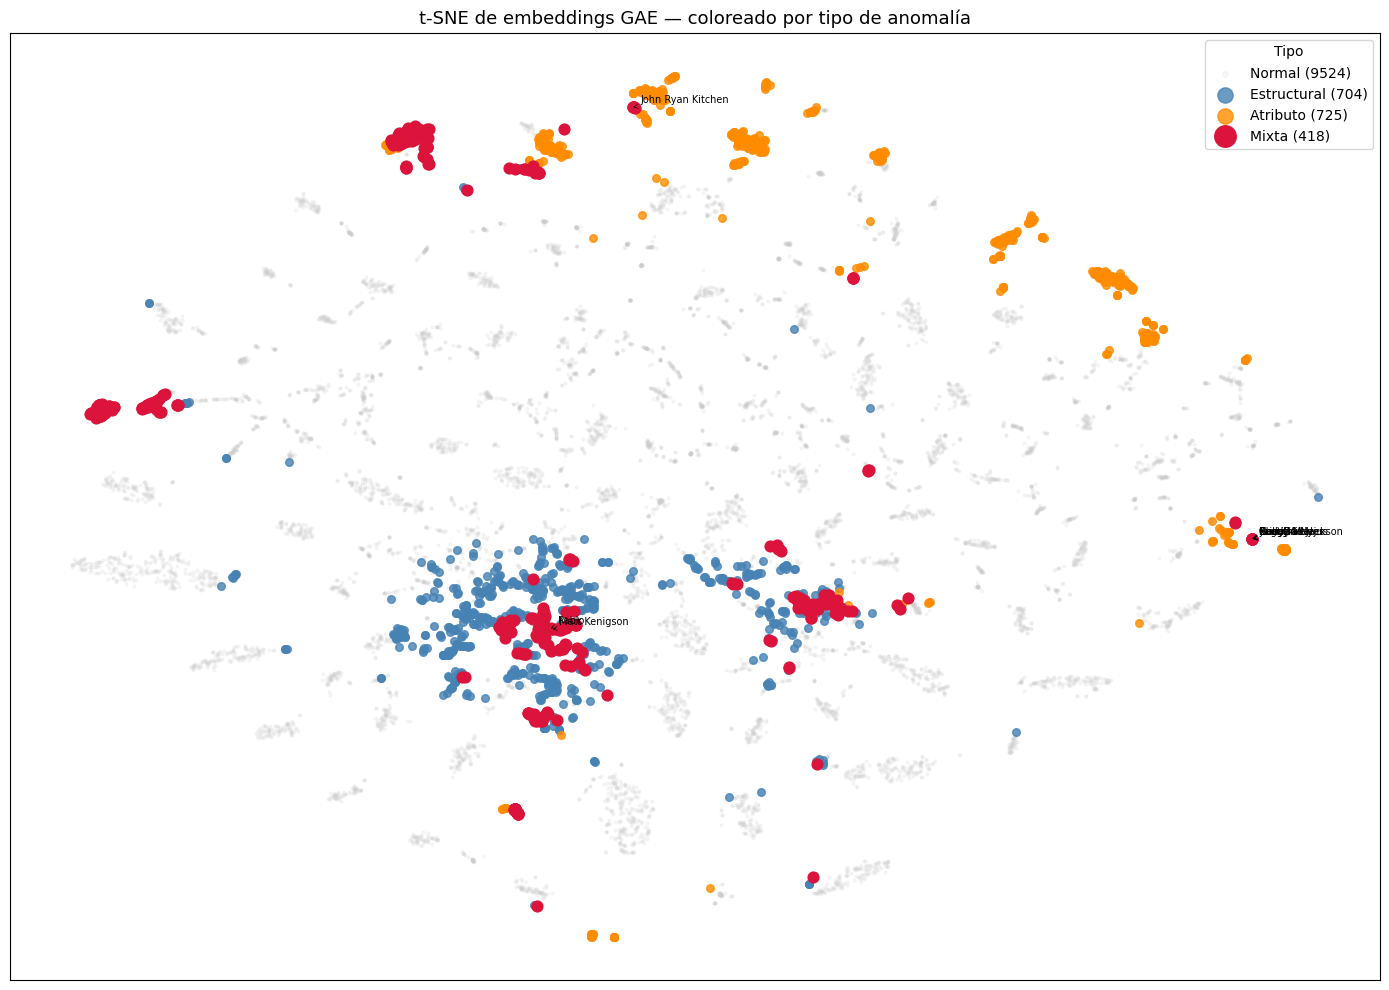

In [40]:
# Visualización 1: coloreado por tipo de anomalía
fig, ax = plt.subplots(figsize=(14, 10))

colors_type = {
    'Normal':      ('#cccccc', 0.15, 4),
    'Estructural': ('steelblue', 0.8, 30),
    'Atributo':    ('darkorange', 0.8, 30),
    'Mixta':       ('crimson', 1.0, 60),
}

for atype, (color, alpha, size) in colors_type.items():
    mask = scores_full['anomaly_type'] == atype
    ax.scatter(z_tsne_gae[mask, 0], z_tsne_gae[mask, 1],
               s=size, alpha=alpha, color=color, label=f'{atype} ({mask.sum()})', zorder=3 if atype != 'Normal' else 1)

# Etiquetamos los top-10 del score de consenso
top10 = scores_full.nlargest(10, 'consensus_score')
for _, row in top10.iterrows():
    idx = row['idx']
    ax.annotate(str(row['name'])[:18], (z_tsne_gae[idx, 0], z_tsne_gae[idx, 1]),
                fontsize=7, xytext=(5, 3), textcoords='offset points',
                arrowprops=dict(arrowstyle='->', color='black', lw=0.5))

ax.set_title('t-SNE de embeddings GAE — coloreado por tipo de anomalía', fontsize=13)
ax.legend(title='Tipo', fontsize=10, markerscale=2)
ax.set_xticks([]); ax.set_yticks([])
ax.grid(False)
plt.tight_layout()
plt.show()

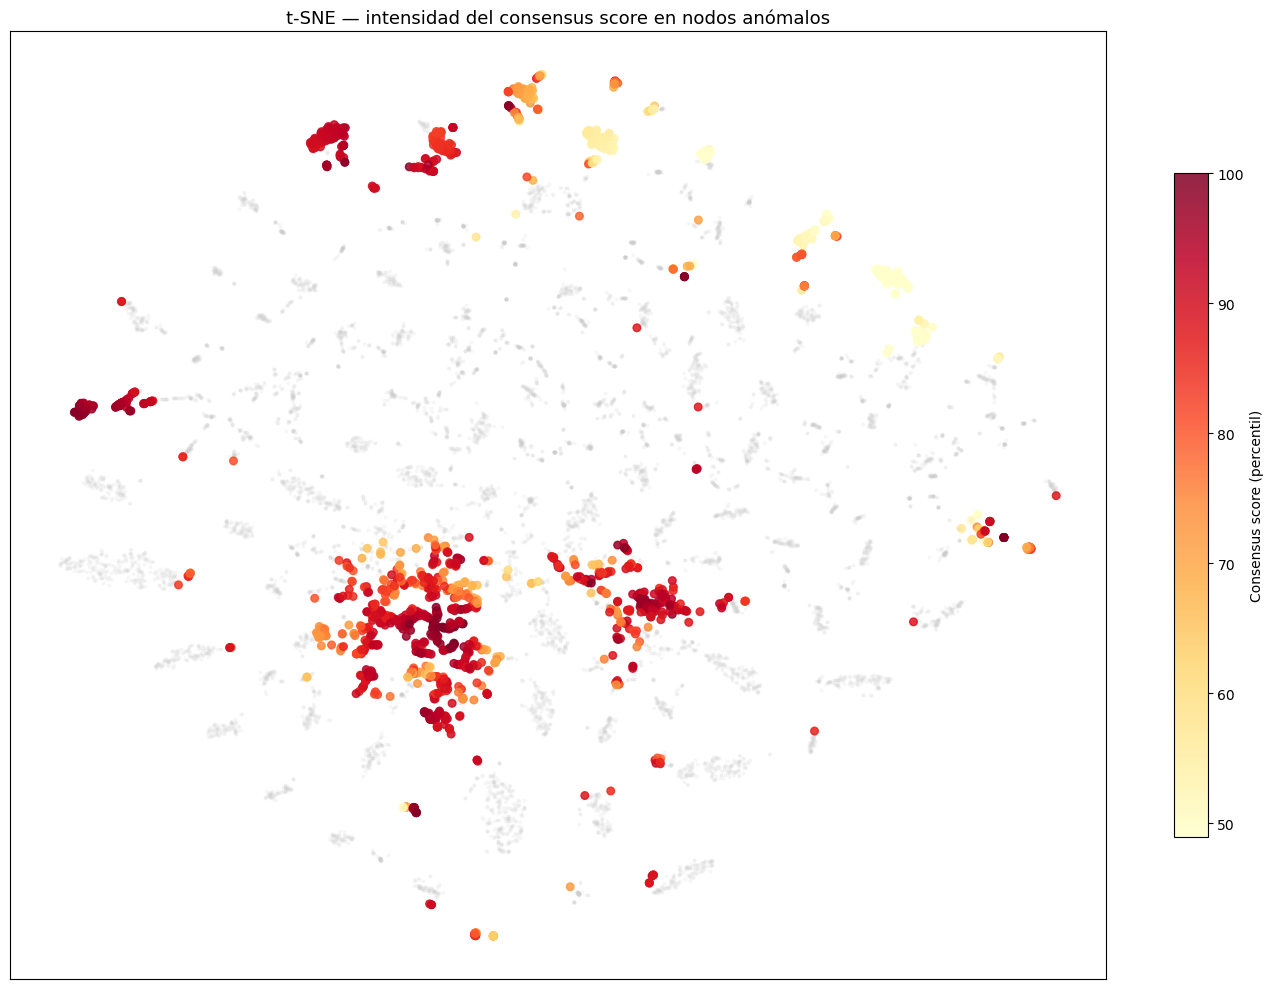

In [41]:
# Visualización 2: coloreado por consensus score (gradiente continuo)
fig, ax = plt.subplots(figsize=(14, 10))

# Nodos normales primero (en gris), anómalos encima
normal_mask = scores_full['anomaly_type'] == 'Normal'
ax.scatter(z_tsne_gae[normal_mask, 0], z_tsne_gae[normal_mask, 1],
           s=4, alpha=0.1, color='#cccccc', zorder=1)

anom_mask = ~normal_mask
sc = ax.scatter(
    z_tsne_gae[anom_mask, 0], z_tsne_gae[anom_mask, 1],
    c=scores_full.loc[anom_mask, 'consensus_score'],
    s=30, alpha=0.85, cmap='YlOrRd', zorder=3,
    vmin=scores_full['consensus_score'].quantile(0.5),
    vmax=100
)
plt.colorbar(sc, ax=ax, label='Consensus score (percentil)', shrink=0.7)

ax.set_title('t-SNE — intensidad del consensus score en nodos anómalos', fontsize=13)
ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.show()

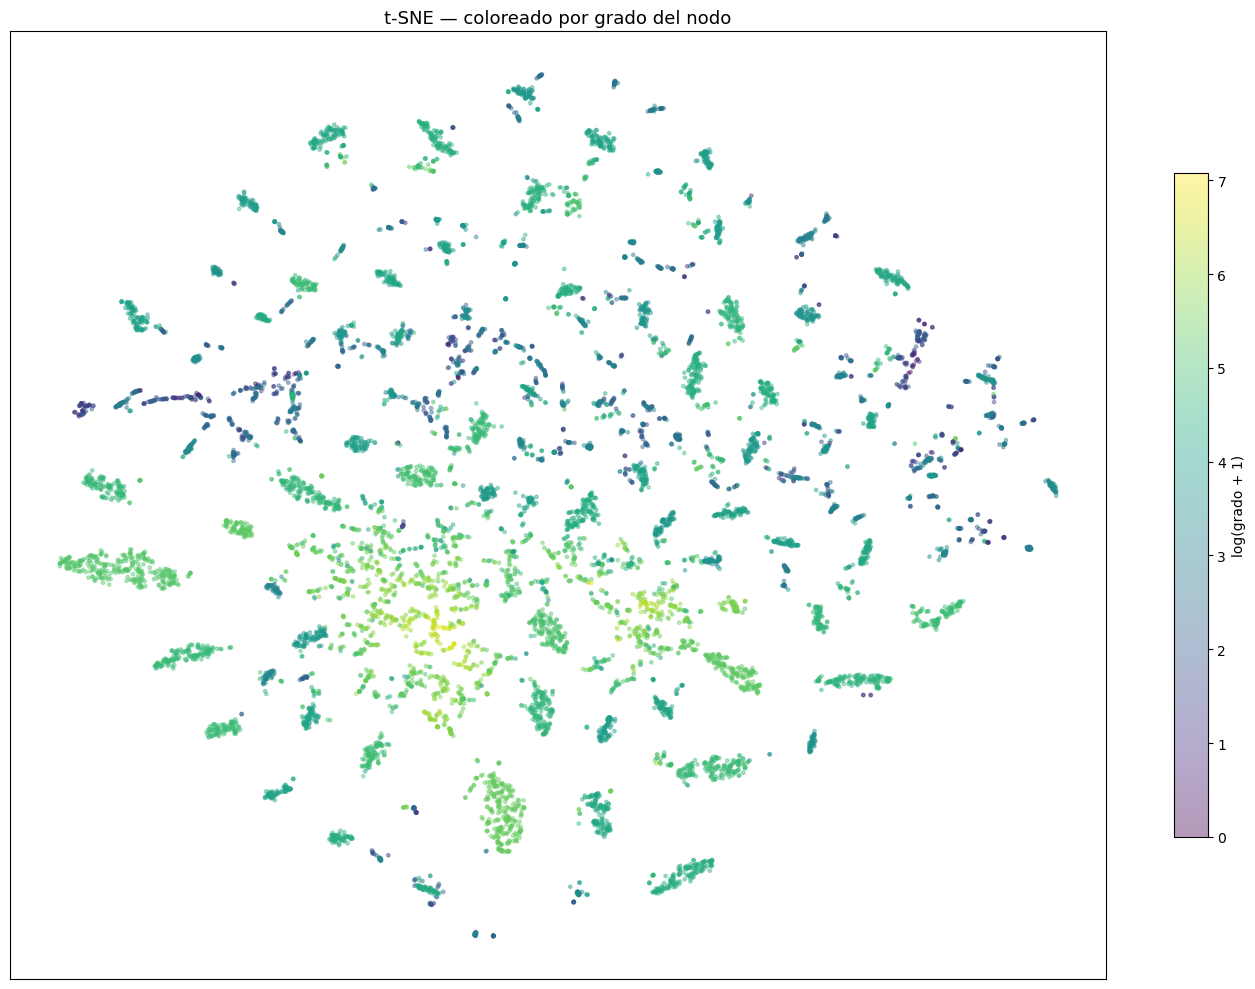

In [42]:
# Visualización 3: coloreado por grado (escala log) — para ver si degree y anomalía se alinean
fig, ax = plt.subplots(figsize=(14, 10))

sc = ax.scatter(
    z_tsne_gae[:, 0], z_tsne_gae[:, 1],
    c=np.log1p(scores_full['degree']),
    s=6, alpha=0.4, cmap='viridis'
)
plt.colorbar(sc, ax=ax, label='log(grado + 1)', shrink=0.7)

ax.set_title('t-SNE — coloreado por grado del nodo', fontsize=13)
ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.show()

In [43]:
# Guardamos el CSV actualizado con el score de consenso y la tipología
scores_full.to_csv(os.path.join(RESULTS_PATH, 'scores_M.csv'), index=False)
print(f'CSV actualizado guardado: {RESULTS_PATH}scores_M.csv')
print(f'Columnas finales: {list(scores_full.columns)}')

# Guardamos también las coordenadas t-SNE para reutilizar en la sección de discusión del TFM
np.save(os.path.join(RESULTS_PATH, 'tsne_M.npy'), z_tsne_gae)
print(f'Coordenadas t-SNE guardadas: {RESULTS_PATH}tsne_M.npy')

CSV actualizado guardado: ../data/results/scores_M.csv
Columnas finales: ['idx', 'member_id', 'gae_recon', 'gae_latent', 'vgae_recon', 'vgae_latent', 'degree', 'name', 'city', 'state', 'pct_gae_recon', 'pct_gae_latent', 'pct_vgae_recon', 'pct_vgae_latent', 'consensus_score', 'signal_structural', 'signal_attribute', 'anomaly_type']
Coordenadas t-SNE guardadas: ../data/results/tsne_M.npy


## Resumen del notebookEn este notebook hemos:1. **Entrenado un GAE y un VGAE** sobre el grafo de miembros con un encoder GCN de 2 capas (3 → 32 → 16) y un decoder de producto interno.2. **Calculado cuatro scores de anomalía**: error de reconstrucción y distancia al centroide latente, para ambos modelos.3. **Comparado los rankings** mediante correlación de Spearman y solapamiento del top-100.4. **[NUEVO] Construido un score de consenso** basado en el rango percentil promedio de los cuatro scores — da un único ranking interpretable y comparable entre grafos.5. **[NUEVO] Tipología de anomalías**: cada nodo se clasifica en estructural (patrón de conexiones atípico), atributo (features inusuales que alejan el embedding del centroide) o mixta (ambas señales).6. **[NUEVO] Spotlight de candidatos del EDA**: verificación sistemática de Pablo, Shalini, Jim H, GEEK by AKEIN Engineering, John Ryan Kitchen y el cluster de Chicago, cruzando la justificación estructural del EDA con los scores del modelo.7. **[NUEVO] Visualización t-SNE** de los embeddings latentes del GAE, coloreada por tipo de anomalía, consensus score y grado — la figura más comunicativa del capítulo 7.1 para la memoria del TFM.Los resultados finales quedan en `data/results/scores_M.csv` (con score de consenso y tipología), `embeddings_M.npz`, `tsne_M.npy` y `history_M.json`.